# Comparing conditions and generating graphs for all conditions

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_1samp

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

In [14]:
#Defining project root
import sys
from pathlib import Path
# Make sure we can import config.py from project root

# One folder up from current notebook location
project_root = Path.cwd().parent.parent.resolve()

# Add subdirectories to path
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'config'))
print(f"Project root: {project_root}")
import config

Project root: /mnt/hdd/anatkorol/Imagination_in_translation


In [15]:
# unite all dataframes into one
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditinos_with_digit_span_w_object_hallucinations.csv")
# old dataframe before accounting for object hallucinations:
#df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditions_with_digit_span.csv")
#make sure df doesn't include gpt-5 as uid!!!
df_gpt = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/gpt_descs.csv")
df_wilma = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/other_datasets/wilmas_drawings_2019/wilmas_data_2019.csv")
df_wilma_desc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/wilmas_drawings_2019/nlp_analysis/wilma_descriptions_with_semantic_tags_all_conditions.csv")

#save paths for graphs (inside analysis) and for objects lists (inside processed data)
graphs_path = Path("/mnt/hdd/anatkorol/Imagination_in_translation/analysis/nlp_analysis/comparing_conditions/graphs")
objects_path = Path("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/objects_lists-3_conditions_w_feedback")

#no feedback dfs:
df_no_feedback_perc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/29032026_pilot_2_perception_no_feedback/nlp_analysis/ppt_trials_w_similarity_semantic_tags.csv").copy()
df_feedback_perc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
df_feedback_perc = df_feedback_perc[df_feedback_perc['uid'] != "gpt-5"]

# df_perc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
# df_im_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/05012026_pilot_2_memory/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
# df_delay_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/09032026_pilot_2_delayed_memory_digit-span/nlp_analysis/ppt_w_gpt_semantic_tags.csv")

In [ ]:
# # wilmas semantic tags based on descriptions:
# df_wilma_perc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/wilmas_drawings_2019/nlp_analysis/perception_drawing_descriptions_semantic_tags.csv")
# df_wilma_im_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/wilmas_drawings_2019/nlp_analysis/immediate_memory_drawing_descriptions_semantic_tags.csv")
# df_wilma_delay_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/wilmas_drawings_2019/nlp_analysis/delayed_memory_drawing_descriptions_semantic_tags.csv")

In [ ]:
# # add conditions to wilma dataframes
# df_wilma_perc['condition'] = 'perception'
# df_wilma_im_mem['condition'] = 'immediate_memory'
# df_wilma_delay_mem['condition'] = 'delayed_memory'
# df_wilma_desc = pd.concat([df_wilma_perc, df_wilma_im_mem, df_wilma_delay_mem], ignore_index=True)

In [ ]:
# df_wilma_desc.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/wilmas_drawings_2019/nlp_analysis/wilma_descriptions_with_semantic_tags_all_conditions.csv", index=False)

In [16]:
#style of bars for graphs:
custom_palette = {
    'perception': '#440154',        # Deep Purple (Viridis start)
    'immediate memory': '#21918c',  # Saturated Turquoise (Viridis mid)
    'delayed memory': '#fde725'      # Bright Yellow (Viridis end)
}
sns.set_theme(style="whitegrid")

In [7]:
df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'item_evaluations',
       'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object',
       'n_invalid_not_in_image', 'diff_in_objects', 'error', 'condition',
       'clip_cosine_distance', 'vgg_fc7_distance', 'clip_vis_text_similarity',
       'token_num'],
      dtype='object')

In [17]:
# data without outlier participant from the delay memory condition
df_clean = df[df['uid'] != 'qfd4qbm61773068899839']

In [74]:
# #add a condition column to each dataframe
# df_perc['condition'] = 'perception'
# df_im_mem['condition'] = 'immediate memory'
# df_delay_mem['condition'] = 'delayed memory'

In [75]:
# # remove the gpt from all, leave a single copy of descriptions
# df_perc = df_perc[df_perc["uid"].astype(str).str.strip() != "gpt-5"].copy()
# df_im_mem = df_im_mem[df_im_mem["uid"].astype(str).str.strip() != "gpt-5"].copy()


In [76]:
# df = pd.concat([df_perc, df_im_mem, df_delay_mem], ignore_index=True)

In [77]:
# df = df[df['uid'] != 'gpt-5']

In [18]:
# turning the category details into actual lists instead of strings
import ast
list_cols = ['objects', 'attr_color', 'spatial_relations'] # 'attr_shape', 'attr_size', 'attr_material', 'attr_texture', 'attr_pose', 'attr_action', 'attr_state', , 'world_knowledge','scene', 'camera_aspects', 'optical_effects', 'subjective_detail'] 

# turning the python strings into real lists
def to_list(x):
    # Already a list
    if isinstance(x, list):
        return x
    # Missing values
    if pd.isna(x):
        return []
    # String that looks like a list
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "null":
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                v = ast.literal_eval(s)
                return v if isinstance(v, list) else []
            except Exception:
                return []
    # Anything else
    return []

def converted (df):
    # Convert columns to real lists
    for c in list_cols:
        if c in df.columns:
            df[c] = df[c].apply(to_list)
    return df


#apply conversion to each df
df = converted(df)
df_gpt = converted(df_gpt)
df_wilma_desc = converted(df_wilma_desc)


In [9]:
# df.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditions_with_digit_span.csv", index=False)

# bar plots for relevant counts - 
all conditions, all attempts
gpt as upper limit/another graph

In [16]:
df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'condition',
       'clip_cosine_distance', 'vgg_fc7_distance', 'clip_vis_text_similarity',
       'token_num'],
      dtype='object')

In [11]:

# df_gpt.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/gpt_descs.csv", index=False)

In [10]:
selected_columns = ["objects", "spatial_relations", "attr_color"] # , "attr_size", "attr_texture", "camera_aspects"]

In [11]:
# converting wide to long and adding a count column for the number of items in each category
# required id columns (adjust if your names differ)
id_cols = ["condition", "attempt", "uid", "gt"]

long = df.melt(
    id_vars=id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

def safe_len(x):
    """Length for list-like; 0 for NaN/None; 1 for scalar non-list values."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x)
    return 1

long["count"] = long["items"].apply(safe_len)

# Keep category order as selected_columns
long["category"] = pd.Categorical(long["category"], categories=selected_columns, ordered=True)

In [12]:
long.head(3)

,condition,attempt,uid,gt,category,items,count
0,perception,1,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",10
1,perception,2,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",11
2,perception,3,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",11


In [16]:
# long.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/long_pilot_data_with_digit_span.csv", index=False)

In [37]:
long.columns

Index(['condition', 'original_name', 'gt', 'category', 'items', 'count'], dtype='object')

In [87]:
#transforming the data using square root:
long['sqrt_count'] = np.sqrt(long['count'])
long

,condition,attempt,uid,gt,category,items,count,sqrt_count
0,perception,1,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",10,3.162278
1,perception,2,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",11,3.316625
2,perception,3,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",11,3.316625
3,perception,1,c2s9h6gg1765201285699,bedroom_l.jpg,objects,"[bedroom, ceiling, bed, pictures, window, duve...",20,4.472136
4,perception,2,c2s9h6gg1765201285699,bedroom_l.jpg,objects,"[bedroom, ceiling, bed, pictures, window, duve...",20,4.472136
...,...,...,...,...,...,...,...,...
1615,delayed memory,2,puqz4woy1773084496016,conference_room_h.jpg,camera_aspects,[],0,0.000000
1616,delayed memory,3,puqz4woy1773084496016,conference_room_h.jpg,camera_aspects,[],0,0.000000
1617,delayed memory,1,puqz4woy1773084496016,lighthouse_h.jpg,camera_aspects,[shot on a digital cam],1,1.000000
1618,delayed memory,2,puqz4woy1773084496016,lighthouse_h.jpg,camera_aspects,[shot on a digital cam],1,1.000000


In [ ]:
# long.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/long_pilot_data_with_digit_span.csv", index=False)

# simple aggregation without participant variability
## These tabs are currently not in use - skip to "with participant variability" section below

In [41]:
#great aggregation but no variance per participant
# # Assuming your dataframe is named 'df'
# # Aggregating across participants (uid) and images (gt) - they are averaged out in the process, so we get a single mean count per category/condition/attempt
condition_order = ['perception', 'immediate memory', 'delayed memory']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)

agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()

# Sort for consistent plotting (Attempt 1, 2, 3)
agg_df = agg_df.sort_values(by=['category', 'condition', 'attempt'])


/tmp/ipykernel_586920/987148115.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [42]:
agg_df

,category,condition,attempt,count
0,objects,perception,1,7.600000
1,objects,perception,2,8.433333
2,objects,perception,3,9.033333
3,objects,immediate memory,1,6.433333
4,objects,immediate memory,2,6.566667
5,objects,immediate memory,3,6.400000
6,objects,delayed memory,1,6.266667
7,objects,delayed memory,2,6.966667
8,objects,delayed memory,3,7.266667
9,spatial_relations,perception,1,3.400000


In [27]:
# Setting up the visual style
sns.set_theme(style="whitegrid")

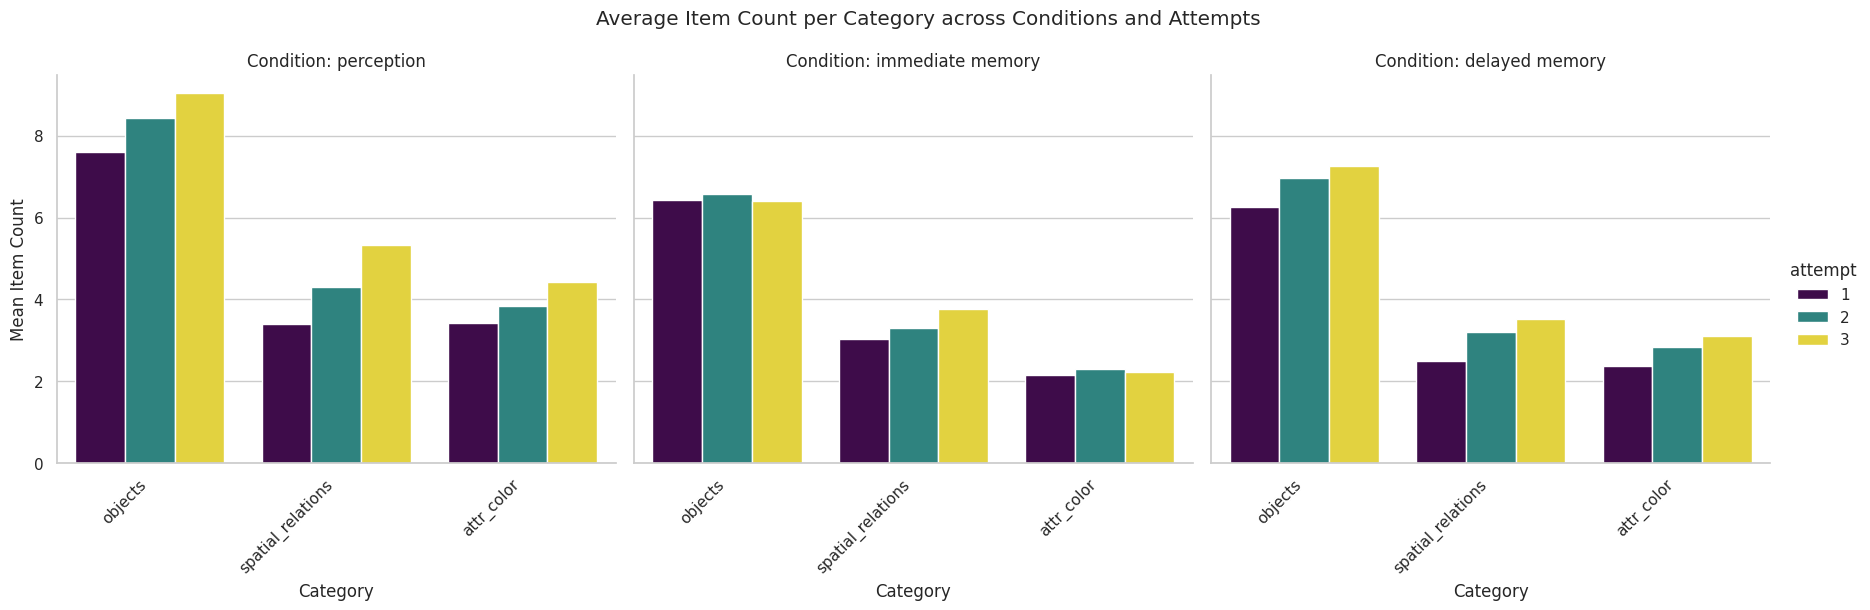

In [28]:


# Creating the faceted bar plot
g = sns.catplot(
    data=agg_df, 
    x='category', 
    y='count', 
    hue='attempt', 
    col='condition', 
    kind='bar',
    palette='viridis',
    height=5, 
    aspect=1.2
)
# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Customizing labels and titles
g.set_axis_labels("Category", "Mean Item Count")
g.set_titles("Condition: {col_name}")
g.fig.suptitle('Average Item Count per Category across Conditions and Attempts', y=1.05)

# plt.savefig('category_analysis_plot.png', bbox_inches='tight')
plt.show()

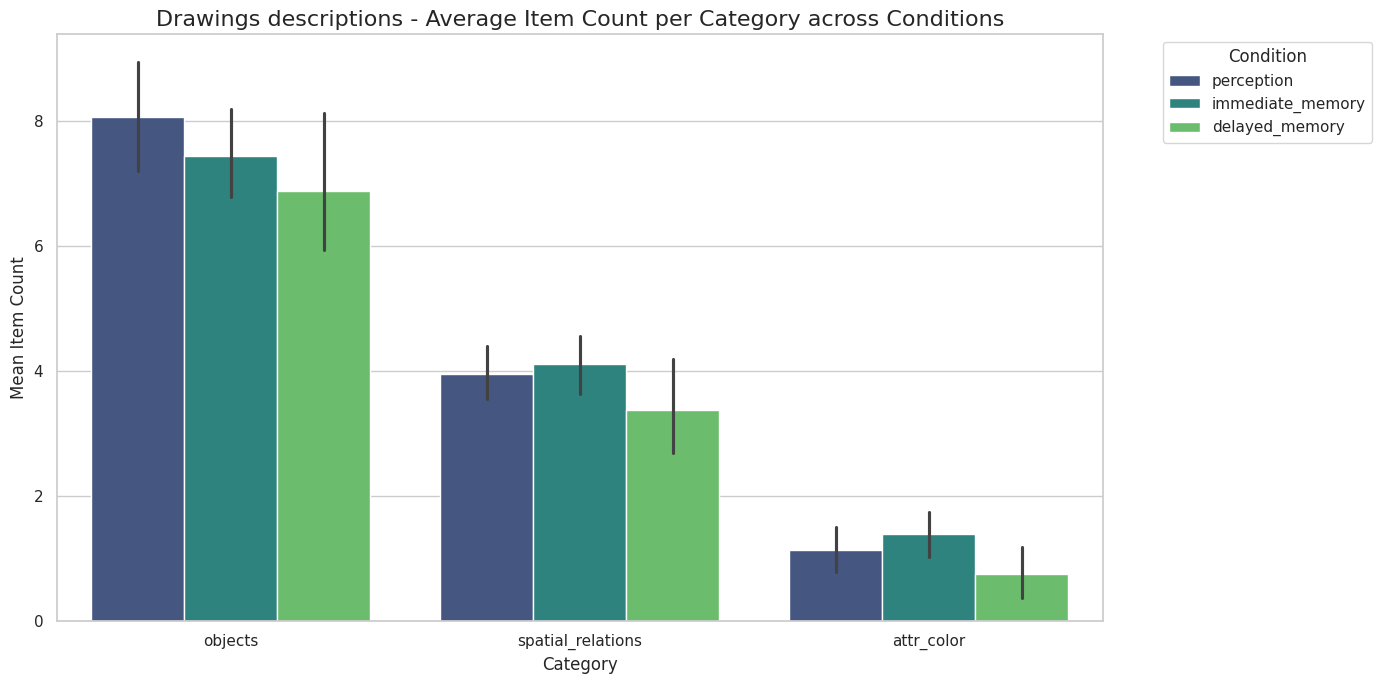

In [43]:
# same analysis but with wilma's descriptions:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# 1. Define the columns of interest
selected_columns = ["objects", "spatial_relations", "attr_color", "attr_size", "attr_texture"]

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the ID columns and categories
id_cols = ["condition", "original_name", "gt"] 
selected_columns = ["objects", "spatial_relations", "attr_color"] # , "attr_size", "attr_texture"]

# 2. Melt the dataframe to turn columns into rows (Wide to Long)
long = df_wilma_desc.melt(
    id_vars=id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

# 3. Apply the counting logic
def safe_len(x):
    """Length for list-like; 0 for NaN/None; 1 for scalar non-list values."""
    if x is None or (isinstance(x, (float, int)) and pd.isna(x)):
        return 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x)
    return 1

long["count"] = long["items"].apply(safe_len)

# 4. Enforce categorical order for categories
long["category"] = pd.Categorical(long["category"], categories=selected_columns, ordered=True)

# 5. Visualize the counts across conditions
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Create the bar chart: each category has the three conditions side-by-side
sns.barplot(
    data=long, 
    x='category', 
    y='count', 
    hue='condition',
    palette='viridis'
)

plt.title('Drawings descriptions - Average Item Count per Category across Conditions', fontsize=16)
plt.ylabel('Mean Item Count', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# # Save outputs
# plt.savefig('wilma_long_counts_summary.png', dpi=300)
# long.to_csv('df_wilma_long_counts.csv', index=False)



In [ ]:
#plotting using mean data - currently doesn't work but I leave it
import plotly.graph_objects as go
import pandas as pd

# 1. Prepare Data
condition_order = ['perception', 'immediate memory', 'delayed memory']
# Ensure it's categorical for sorting, but we'll use strings for grouping
agg_df['condition'] = pd.Categorical(agg_df['condition'], categories=condition_order, ordered=True)
agg_df = agg_df.sort_values(['category', 'condition', 'attempt'])

# Bar data: Mean of attempts (using observed=True to fix your previous warning)
bar_df = agg_df.groupby(['category', 'condition'], as_index=False, observed=True)['count'].mean()

# 2. Create Figure
fig = go.Figure()

# 3. Add the Bars (Viridis Palette)
# Viridis Hex: Dark Purple, Teal/Green, Yellow
viridis_colors = ['#440154', '#21918c', '#fde725'] 

for i, cond in enumerate(condition_order):
    cond_data = bar_df[bar_df['condition'] == cond]
    fig.add_trace(go.Bar(
        x=cond_data['category'],
        y=cond_data['count'],
        name=cond,
        marker_color=viridis_colors[i],
        opacity=0.6,
        offsetgroup=cond  # String name of the condition
    ))

# 4. Add the Dots (Attempt 1, 2, 3)
# We loop through attempts. Each dot must know which BAR (condition) it belongs to.
attempt_colors = ['#FF4136', '#2ECC40', '#0074D9'] # Red, Green, Blue

for j, att in enumerate([1, 2, 3]):
    att_data = agg_df[agg_df['attempt'] == att]
    
    fig.add_trace(go.Scatter(
        x=att_data['category'],
        y=att_data['count'],
        name=f"Attempt {att}",
        mode='markers',
        marker=dict(
            color=attempt_colors[j], 
            size=10, 
            line=dict(width=1, color='black')
        ),
        # Crucial fix: Convert the condition column to strings so Plotly accepts them
        offsetgroup=att_data['condition'].astype(str),
        alignmentgroup=att_data['condition'].astype(str)
    ))

# 5. Styling
fig.update_layout(
    barmode='group',
    title="Count by Category and Condition with Attempt Breakdown",
    xaxis_title="Category",
    yaxis_title="Mean Count",
    xaxis_tickangle=-45,
    legend_title="Legend",
    template="plotly_white"
)

fig.show()

ValueError: 
    Invalid value of type 'pandas.core.series.Series' received for the 'alignmentgroup' property of scatter
        Received value: 0           perception
3     immediate memory
6       delayed memory
9           perception
12    immediate memory
15      delayed memory
18          perception
21    immediate memory
24      delayed memory
Name: condition, dtype: object

    The 'alignmentgroup' property is a string and must be specified as:
      - A string
      - A number that will be converted to a string

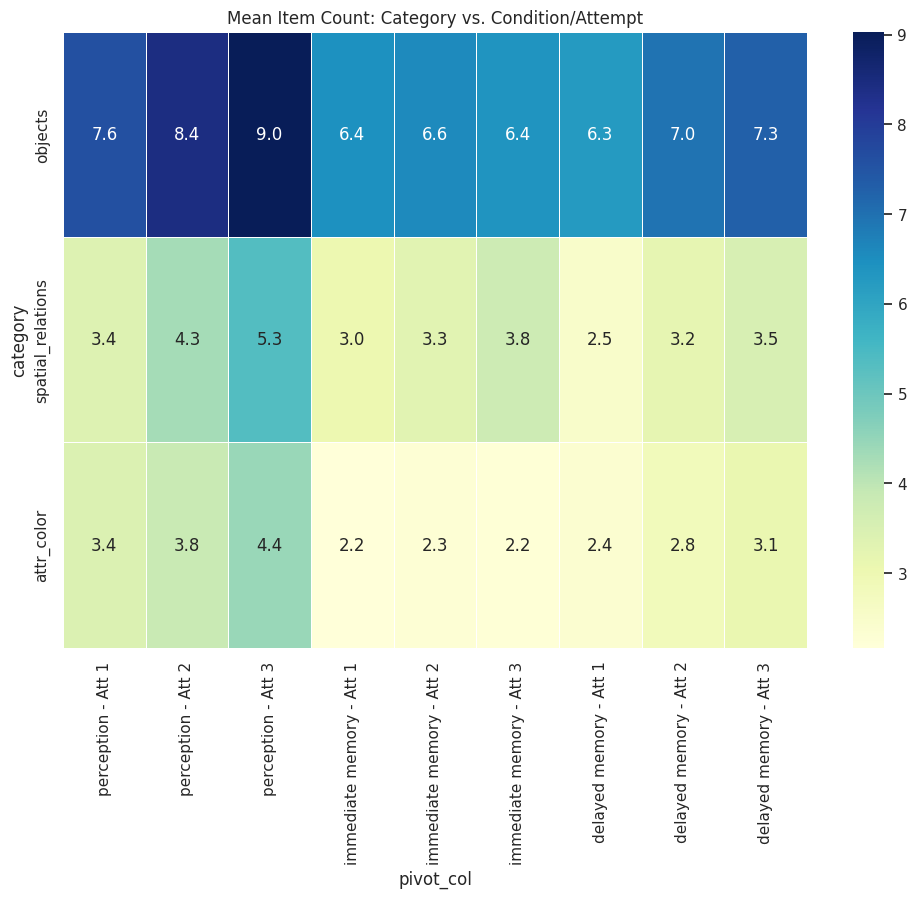

In [35]:
# Create a combined label for the heatmap columns
agg_df['pivot_col'] = agg_df['condition'].astype(str) + " - Att " + agg_df['attempt'].astype(str)

pivot_df = agg_df.pivot(index="category", columns="pivot_col", values="count")

# Reorder columns to follow your condition order
cols = []
for cond in condition_order:
    for att in [1, 2, 3]:
        cols.append(f"{cond} - Att {att}")
pivot_df = pivot_df[cols]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=.5)
plt.title("Mean Item Count: Category vs. Condition/Attempt")
plt.show()

# with participant variability

In [52]:
long

,condition,attempt,uid,gt,category,items,count
0,perception,1,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",10
1,perception,2,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",11
2,perception,3,c2s9h6gg1765201285699,living_room_h.jpg,objects,"[living room, wall, floor mat, floor, coffee t...",11
3,perception,1,c2s9h6gg1765201285699,bedroom_l.jpg,objects,"[bedroom, ceiling, bed, pictures, window, duve...",20
4,perception,2,c2s9h6gg1765201285699,bedroom_l.jpg,objects,"[bedroom, ceiling, bed, pictures, window, duve...",20
...,...,...,...,...,...,...,...
805,delayed memory,2,puqz4woy1773084496016,conference_room_h.jpg,attr_color,"[red, black]",2
806,delayed memory,3,puqz4woy1773084496016,conference_room_h.jpg,attr_color,"[purple, yellow, light blue, white, red, black]",6
807,delayed memory,1,puqz4woy1773084496016,lighthouse_h.jpg,attr_color,[orange],1
808,delayed memory,2,puqz4woy1773084496016,lighthouse_h.jpg,attr_color,"[orange, dark blue]",2


In [21]:
condition_order = ['perception', 'immediate memory', 'delayed memory']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean the Condition names and set the order
# Ensure your strings match these exactly (check for capitalization/spaces)
condition_order = ['perception', 'immediate memory', 'delayed memory']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)

# 2. Correct Aggregation
# We include 'condition' in the groupby to keep the participant tied to their group.
# We average the 'count' (averaging across the multiple images 'gt' each person saw).
df_participant = long.groupby(
    ['condition', 'uid', 'category', 'attempt'], 
    as_index=False, 
    observed=True  # IMPORTANT: This prevents pandas from creating empty rows for 
                   # combinations that don't exist (like User A in Condition B)
)['count'].mean()


# 1. choose only 3rd attempt for the plot, as it is the max ability of the participant:
df_attempt_3 = long[long['attempt'] == 3].copy()

# 3. Verify the structure
df_participant.sample(9)
# You should see that any given 'uid' is only ever associated with one 'condition'.

,condition,uid,category,attempt,count
122,delayed memory,puqz4woy1773084496016,spatial_relations,3,4.4
84,immediate memory,oiv8zavj1767639943374,spatial_relations,1,2.4
47,perception,usj6if3d1765309873263,objects,3,8.4
102,immediate memory,tyrfv5eq1767635157270,spatial_relations,1,2.8
48,perception,usj6if3d1765309873263,spatial_relations,1,2.4
25,perception,c2s9h6gg1765201285699,attr_color,2,4.6
96,immediate memory,qn36ndly1767638614323,attr_color,1,1.2
125,delayed memory,puqz4woy1773084496016,attr_color,3,4.2
117,delayed memory,puqz4woy1773084496016,objects,1,7.0


/tmp/ipykernel_586920/1402362008.py:29: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.


/tmp/ipykernel_586920/1402362008.py:29: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.


/tmp/ipykernel_586920/1402362008.py:29: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.




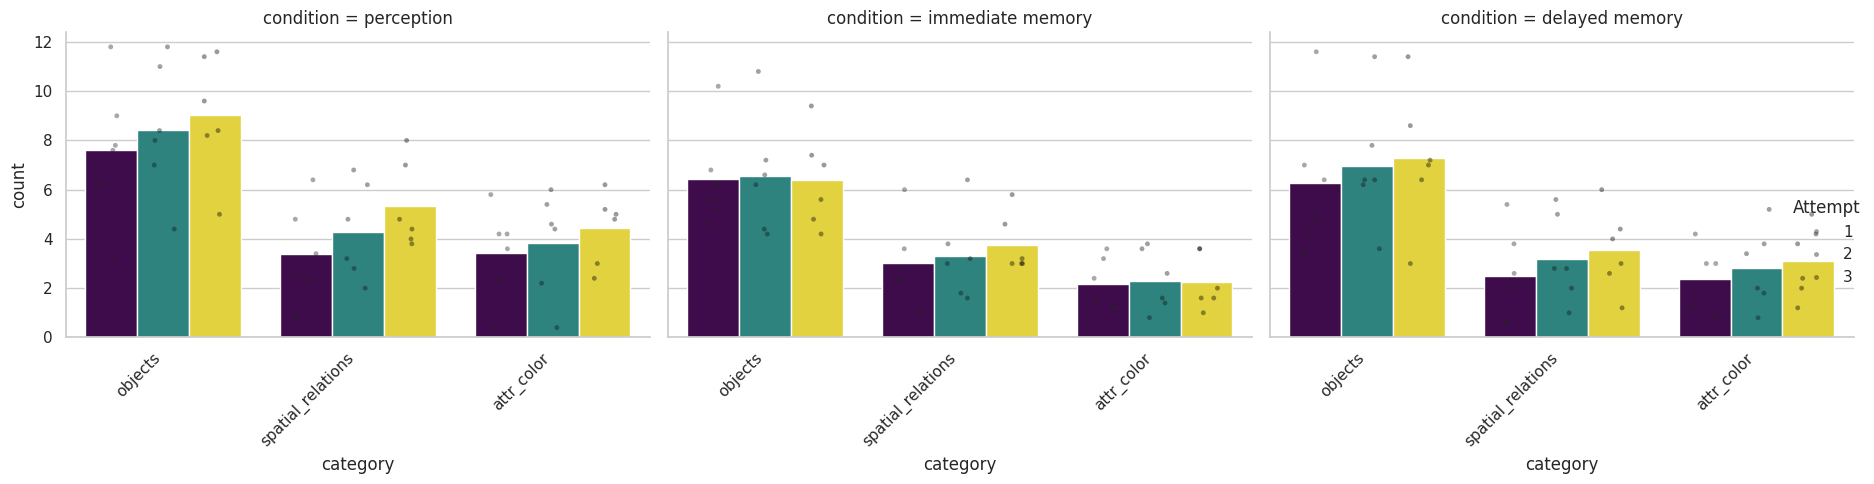

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Choose your colors
bar_palette = "viridis"   # "muted", "deep", or "Dark2" are good for darker bars
dot_color = "black"     # Using a single dark color for dots often looks cleaner

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    df_participant, 
    col="condition", 
    col_order=['perception', 'immediate memory', 'delayed memory'],
    height=5, 
    aspect=1.2
)

def draw_study_data(data, **kwargs):
    ax = plt.gca()
    
    # DARKER BARS: alpha=1.0 makes them fully opaque
    sns.barplot(
        data=data, x="category", y="count", hue="attempt",
        palette=bar_palette, alpha=1.0, errorbar=None, ax=ax
    )
    
    # CONTRASTING DOTS: Using 'black' or '0.2' (dark gray) 
    # dodge=True keeps them aligned with the specific attempt bar
    sns.stripplot(
        data=data, x="category", y="count", hue="attempt",
        color=dot_color, dodge=True, alpha=0.4, size=3.5, jitter=0.2, ax=ax
    )
    
    if ax.get_legend(): ax.get_legend().remove()

g.map_dataframe(draw_study_data)

# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

g.add_legend(title="Attempt")
plt.tight_layout()
plt.savefig(graphs_path / 'tags_count_seperate_conditions_with_ppt_variablity.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_592960/2882520903.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df_attempt_3.groupby(
/tmp/ipykernel_592960/2882520903.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


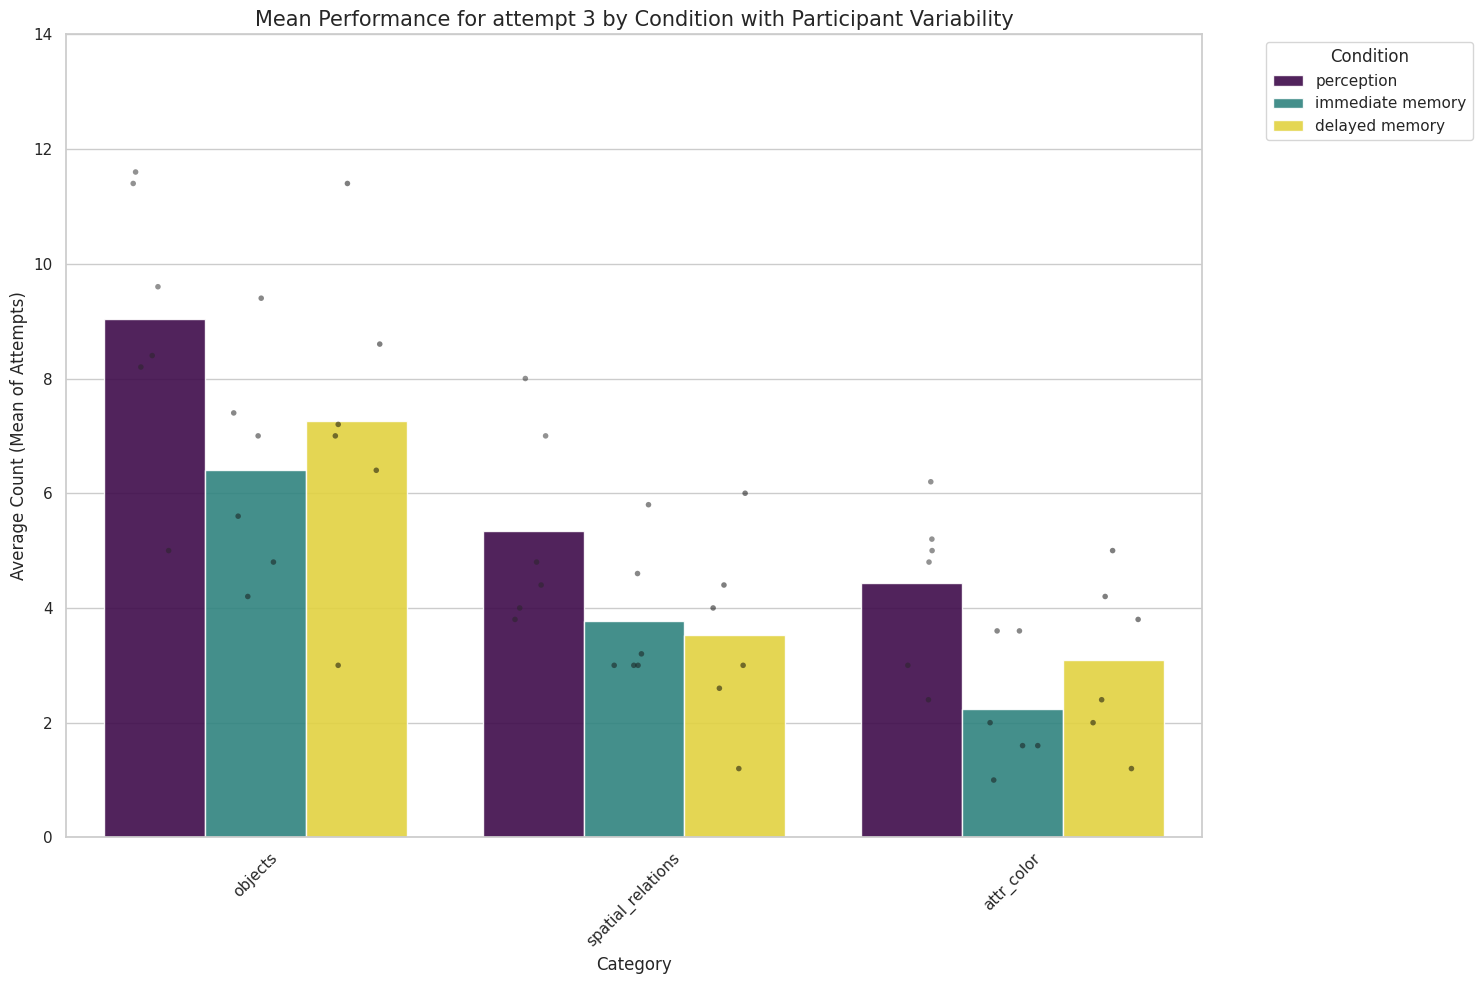

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the Custom High-Contrast Palette ---
# These hex codes are sampled specifically to match your request.
custom_palette = {
    'perception': '#440154',        # Deep Purple (Viridis start)
    'immediate memory': '#21918c',  # Saturated Turquoise (Viridis mid)
    'delayed memory': '#fde725'      # Bright Yellow (Viridis end)
}
sns.set_theme(style="whitegrid")
# 1. choose only 3rd attempt for the plot, as it is the max ability of the participant:
df_attempt_3 = long[long['attempt'] == 3].copy()

# --- 2. Aggregate per participant/category for Attempt 3 ---
# Since we filtered for one attempt, .mean() here just handles multiple 'gt' images
df_plot = df_attempt_3.groupby(
    ['condition', 'uid', 'category'], 
    as_index=False
)['count'].mean()

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# 3. Create the Bar Plot (Remove error bars here)
ax = sns.barplot(
    data=df_plot,
    x='category',
    y='count',
    hue='condition',
    palette=custom_palette,
    alpha=0.9,      # Mzake bars slightly transparent so dots stand out
    errorbar=None   # Remove the standard error bars
)

# 4. Add the individual dots (one per uid)
sns.stripplot(
    data=df_plot,
    x='category',
    y='count',
    hue='condition',
    dodge=True,          
    color='black',       # <-- Changed from palette to a fixed color
    alpha=0.5,           # Transparency makes them subtle but still visible
    jitter=0.2,          
    size=4,              
    legend=False         
)         # Prevent duplicate legend entries


# 5. Customization
plt.title('Mean Performance for attempt 3 by Condition with Participant Variability', fontsize=15)
plt.ylabel('Average Count (Mean of Attempts)')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylim(0, 14)
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Now the same but with *clean data* (single outlier - out)

In [15]:


# turning df clean into a long dataframe:
# converting wide to long and adding a count column for the number of items in each category
# required id columns (adjust if your names differ)
id_cols = ["condition", "attempt", "uid", "gt"]

long_clean = df_clean.melt(
    id_vars=id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

def safe_len(x):
    """Length for list-like; 0 for NaN/None; 1 for scalar non-list values."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x)
    return 1

long_clean["count"] = long_clean["items"].apply(safe_len)

# Keep category order as selected_columns
long_clean["category"] = pd.Categorical(long_clean["category"], categories=selected_columns, ordered=True)

# 1. Clean the Condition names and set the order
# Ensure your strings match these exactly (check for capitalization/spaces)
condition_order = ['perception', 'immediate memory', 'delayed memory']
long_clean['condition'] = pd.Categorical(long_clean['condition'], categories=condition_order, ordered=True)

# 2. Correct Aggregation
# We include 'condition' in the groupby to keep the participant tied to their group.
# We average the 'count' (averaging across the multiple images 'gt' each person saw).
df_participant = long_clean.groupby(
    ['condition', 'uid', 'category', 'attempt'], 
    as_index=False, 
    observed=True  # IMPORTANT: This prevents pandas from creating empty rows for 
                   # combinations that don't exist (like User A in Condition B)
)['count'].mean()


# 1. choose only 3rd attempt for the plot, as it is the max ability of the participant:
df_attempt_3 = long_clean[long_clean['attempt'] == 3].copy()

# 3. Verify the structure
df_participant.sample(9)
# You should see that any given 'uid' is only ever associated with one 'condition'.

NameError: name 'df_clean' is not defined

/tmp/ipykernel_592960/2078786450.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_592960/2078786450.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_592960/2078786450.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


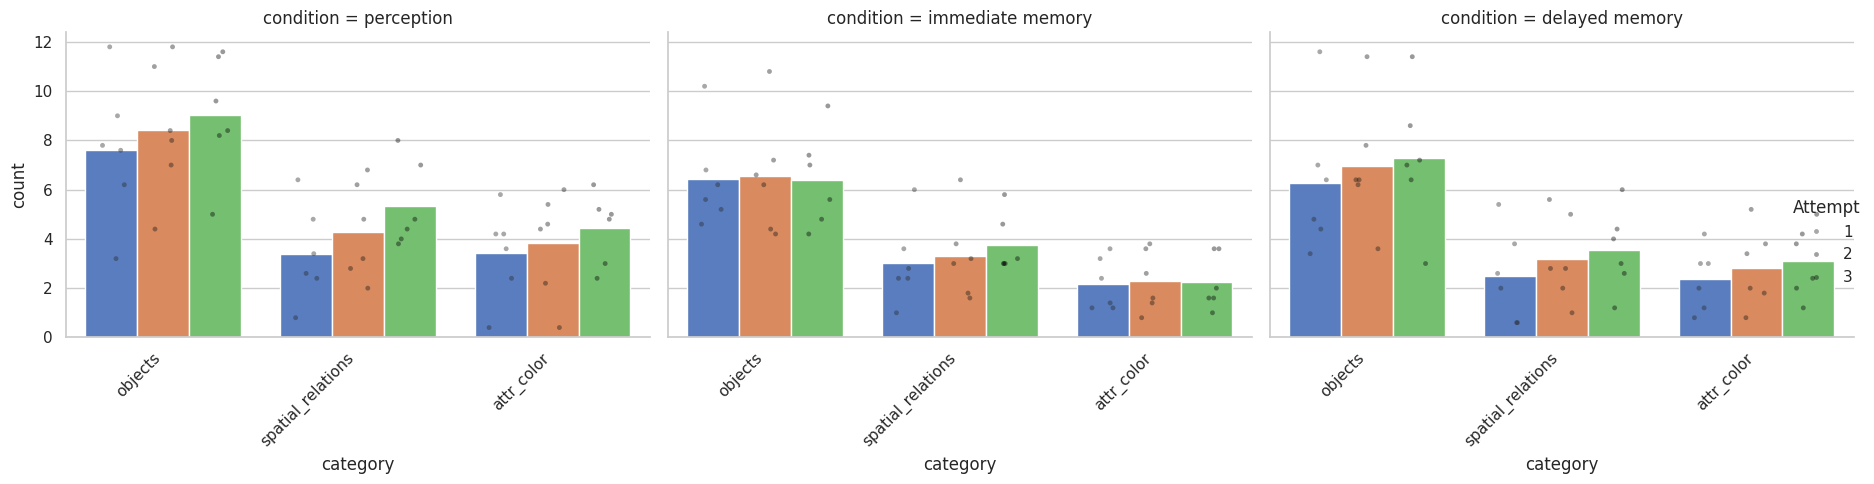

In [58]:

# 1. Choose your colors
bar_palette = "muted"   # "muted", "deep", or "Dark2" are good for darker bars
dot_color = "black"     # Using a single dark color for dots often looks cleaner

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    df_participant, 
    col="condition", 
    col_order=['perception', 'immediate memory', 'delayed memory'],
    height=5, 
    aspect=1.2
)

def draw_study_data(data, **kwargs):
    ax = plt.gca()
    
    # DARKER BARS: alpha=1.0 makes them fully opaque
    sns.barplot(
        data=data, x="category", y="count", hue="attempt",
        palette=bar_palette, alpha=1.0, errorbar=None, ax=ax
    )
    
    # CONTRASTING DOTS: Using 'black' or '0.2' (dark gray) 
    # dodge=True keeps them aligned with the specific attempt bar
    sns.stripplot(
        data=data, x="category", y="count", hue="attempt",
        color=dot_color, dodge=True, alpha=0.4, size=3.5, jitter=0.2, ax=ax
    )
    
    if ax.get_legend(): ax.get_legend().remove()

g.map_dataframe(draw_study_data)

# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

g.add_legend(title="Attempt")
plt.tight_layout()
#plt.savefig(graphs_path / 'tags_count_seperate_conditions_with_ppt_variablity_clean_data.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_592960/736752246.py:37: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


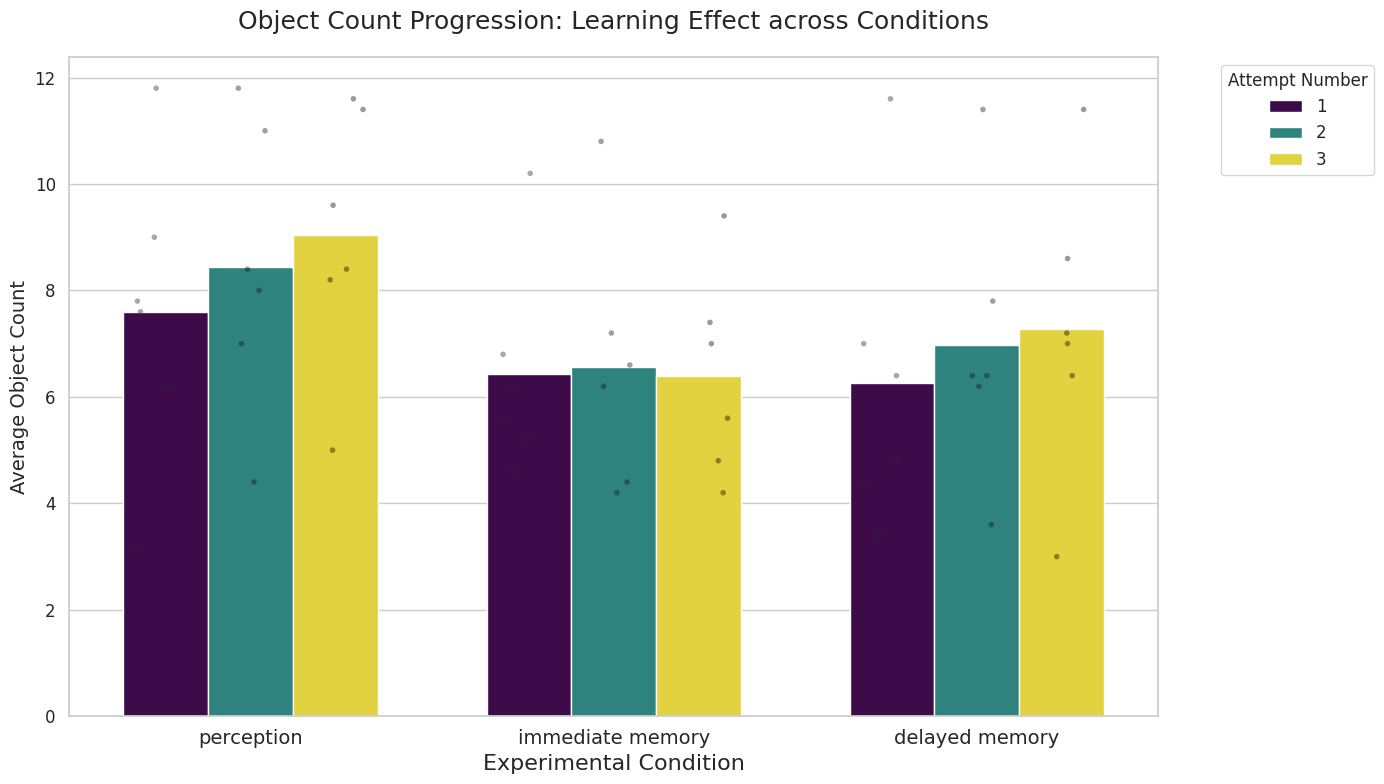

In [72]:
#learning curve - per attempt - only for objects

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for Objects category only
df_objects = df_participant[df_participant['category'] == 'objects'].copy()

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# 3. Define our standard high-contrast Viridis colors for the attempts
# This ensures Attempt 1 is Purple, 2 is Teal, and 3 is Yellow
#attempt_palette = sns.color_palette("viridis", 3)
#style of bars for graphs:
attempt_custom_palette = {
    1: '#440154', # Deep Purple
    2: '#21918c', # Teal
    3: '#fde725'  # Bright Yellow
}
# 4. Create the Bar Plot
# X is now 'condition', and the group (hue) is 'attempt'
ax = sns.barplot(
    data=df_objects,
    x='condition',
    y='count',
    hue='attempt',
    order=['perception', 'immediate memory', 'delayed memory'],
    palette=attempt_custom_palette,
    alpha=1,      # High saturation for rich colors
    width=0.7,      # Thinner bars for a cleaner look
    errorbar=None   # Removing error bars to focus on participant dots
)

# 5. Add Black Dots for Participant Variability
sns.stripplot(
    data=df_objects,
    x='condition',
    y='count',
    hue='attempt',
    order=['perception', 'immediate memory', 'delayed memory'],
    dodge=True,          # Aligns dots with their specific attempt bar
    color='black',       # Fixed black color for high visibility
    alpha=0.4,           
    jitter=0.15,          
    size=4,              
    legend=False         # Prevent duplicate legend entries
)

# 6. Final Polish & Font Sizes
plt.title('Object Count Progression: Learning Effect across Conditions', fontsize=18, pad=20)
plt.ylabel('Average Object Count', fontsize=14)
plt.xlabel('Experimental Condition', fontsize=16)

# Increase font size for condition labels on x-axis
plt.xticks(fontsize=14) 
plt.yticks(fontsize=12)

# Legend customization
plt.legend(title='Attempt Number', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_592960/257912570.py:37: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


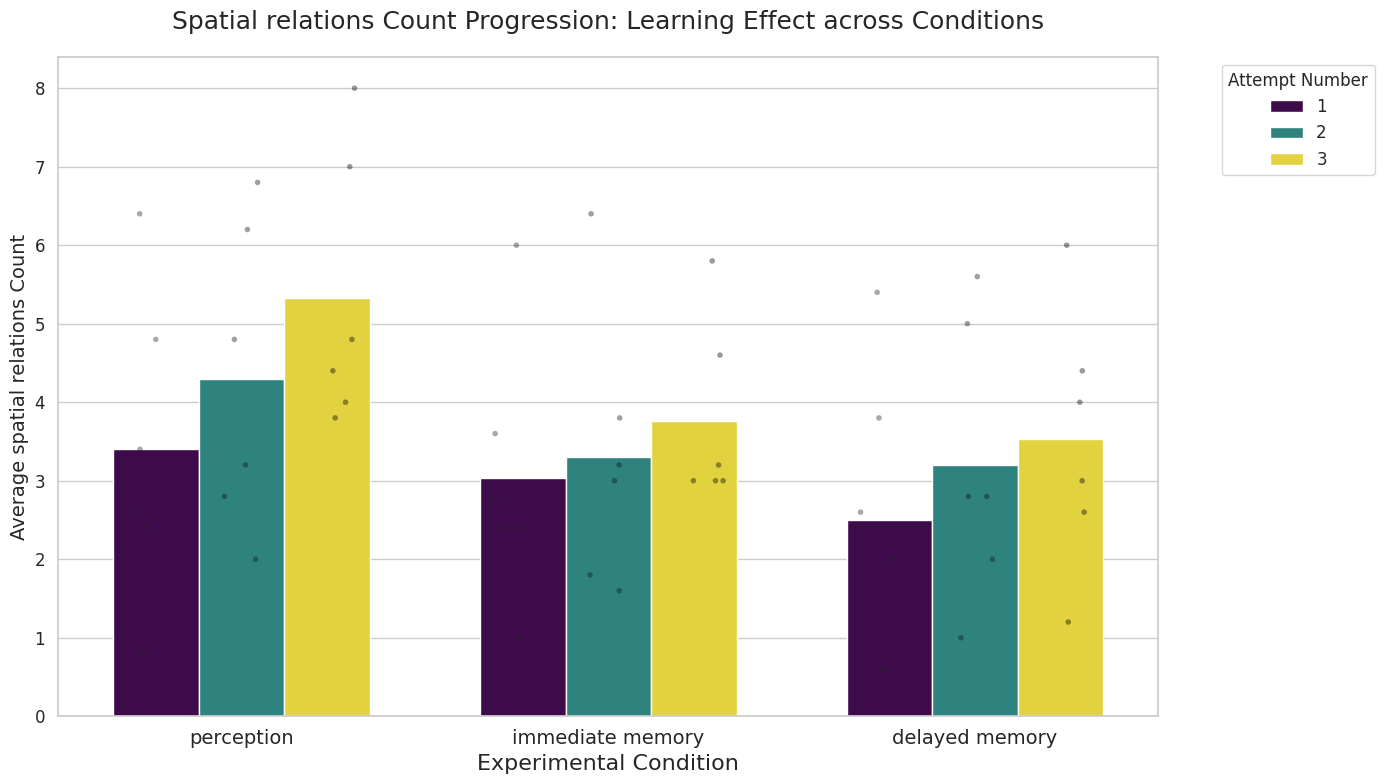

In [75]:
#learning curve - per attempt - only for spatial relations

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for Objects category only
df_spatial = df_participant[df_participant['category'] == 'spatial_relations'].copy()

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# 3. Define our standard high-contrast Viridis colors for the attempts
# This ensures Attempt 1 is Purple, 2 is Teal, and 3 is Yellow
#attempt_palette = sns.color_palette("viridis", 3)
#style of bars for graphs:
attempt_custom_palette = {
    1: '#440154', # Deep Purple
    2: '#21918c', # Teal
    3: '#fde725'  # Bright Yellow
}
# 4. Create the Bar Plot
# X is now 'condition', and the group (hue) is 'attempt'
ax = sns.barplot(
    data=df_spatial,
    x='condition',
    y='count',
    hue='attempt',
    order=['perception', 'immediate memory', 'delayed memory'],
    palette=attempt_custom_palette,
    alpha=1,      # High saturation for rich colors
    width=0.7,      # Thinner bars for a cleaner look
    errorbar=None   # Removing error bars to focus on participant dots
)

# 5. Add Black Dots for Participant Variability
sns.stripplot(
    data=df_spatial,
    x='condition',
    y='count',
    hue='attempt',
    order=['perception', 'immediate memory', 'delayed memory'],
    dodge=True,          # Aligns dots with their specific attempt bar
    color='black',       # Fixed black color for high visibility
    alpha=0.4,           
    jitter=0.15,          
    size=4,              
    legend=False         # Prevent duplicate legend entries
)

# 6. Final Polish & Font Sizes
plt.title('Spatial relations Count Progression: Learning Effect across Conditions', fontsize=18, pad=20)
plt.ylabel('Average spatial relations Count', fontsize=14)
plt.xlabel('Experimental Condition', fontsize=16)

# Increase font size for condition labels on x-axis
plt.xticks(fontsize=14) 
plt.yticks(fontsize=12)

# Legend customization
plt.legend(title='Attempt Number', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_592960/2118821476.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df_attempt_3.groupby(


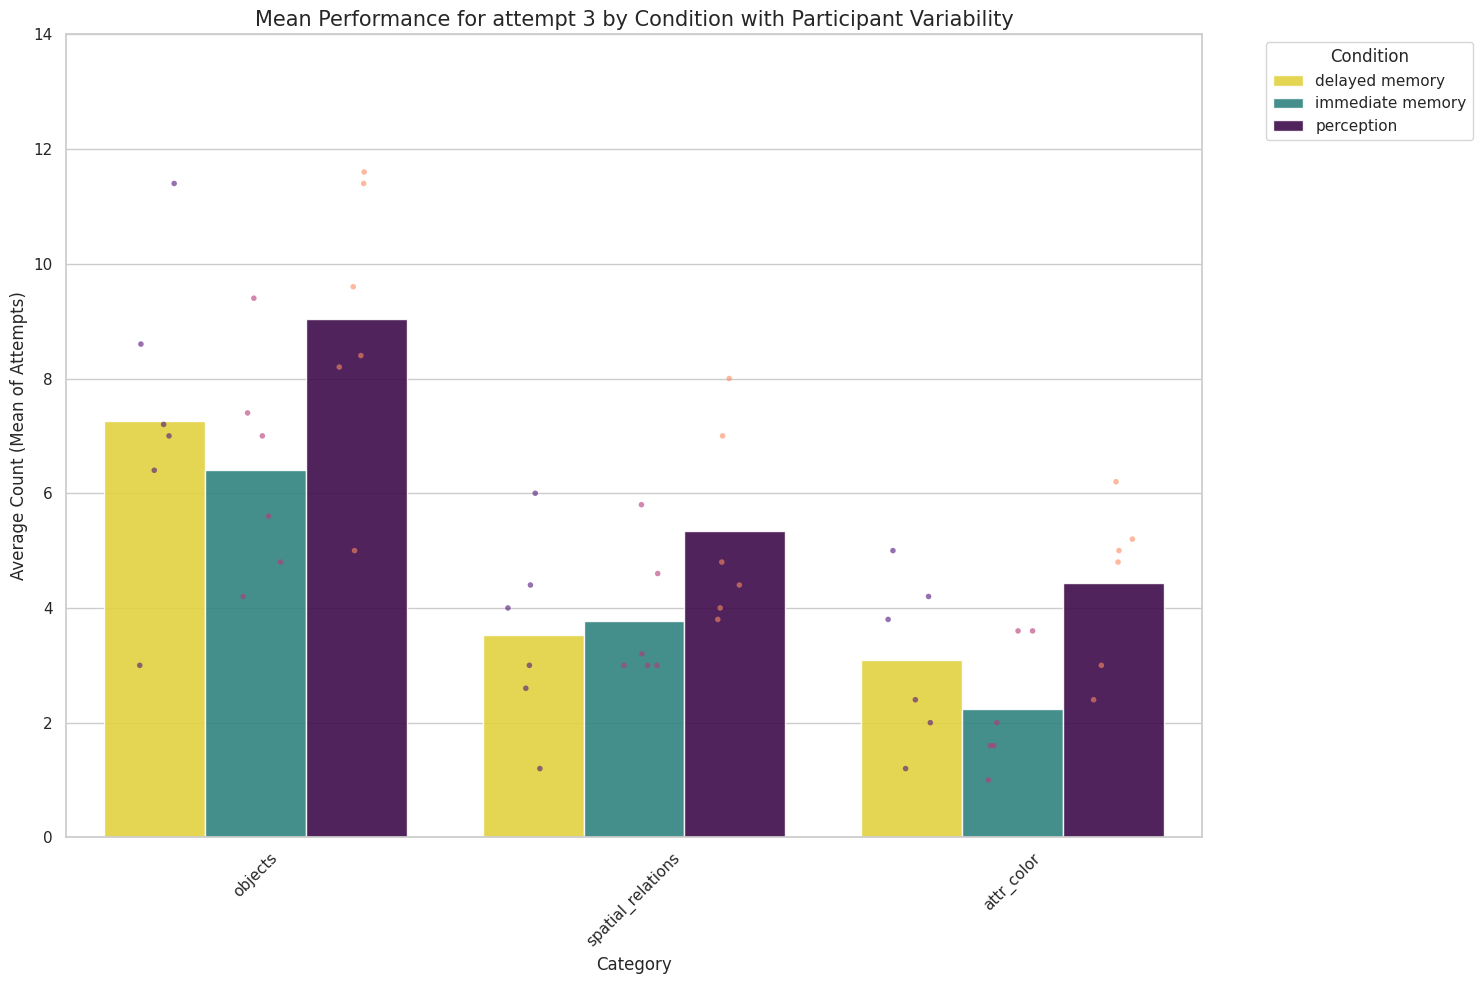

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## this is supposed to be with clean data...
# 1. choose only 3rd attempt for the plot, as it is the max ability of the participant:
df_attempt_3 = long[long['attempt'] == 3].copy()

# --- 2. Aggregate per participant/category for Attempt 3 ---
# Since we filtered for one attempt, .mean() here just handles multiple 'gt' images
df_plot = df_attempt_3.groupby(
    ['condition', 'uid', 'category'], 
    as_index=False
)['count'].mean()

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# 3. Create the Bar Plot (Remove error bars here)
ax = sns.barplot(
    data=df_plot,
    x='category',
    y='count',
    hue='condition',
    palette=custom_palette,
    alpha=0.9,      # Make bars slightly transparent so dots stand out
    errorbar=None   # Remove the standard error bars
)

# 4. Add the individual dots (one per uid)
sns.stripplot(
    data=df_plot,
    x='category',
    y='count',
    hue='condition',
    dodge=True,          # Shift dots to align with the specific bars
    palette='magma',
    alpha=0.6,           # Transparency for dots
    jitter=0.2,          # Spread dots horizontally so they don't overlap
    size=4,              # Size of the dots
    legend=False         # Prevent duplicate legend entries
)

# 5. Customization
plt.title('Mean Performance for attempt 3 by Condition with Participant Variability', fontsize=15)
plt.ylabel('Average Count (Mean of Attempts)')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylim(0, 14)
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# adding gpt to measures

In [20]:
# first let's test which gpt-5 descs to choose (remember they differ in their verbosity:)
#make a bar comparison of counts for each type of description (they differ in column "verbosity" as low, mediu, and high)
# Assuming selected_columns contains your count categories (objects, attr_color, etc.)
gpt_id_cols = ["uid", "gt", "verbosity"] 

gpt_long = df_gpt.melt(
    id_vars=gpt_id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

# Apply your safe_len function to get the counts
gpt_long["count"] = gpt_long["items"].apply(safe_len)

In [24]:
gpt_long

,uid,gt,verbosity,category,items,count
0,gpt-5,bedroom_l.jpg,low,objects,"[bed, post, duvet, pillow, print, headboard, w...",27
1,gpt-5,bedroom_l.jpg,medium,objects,"[bedroom, window, bed, posts, duvet, pillows, ...",24
2,gpt-5,bedroom_l.jpg,high,objects,"[bed, duvet, sheets, pillows, prints, headboar...",25
3,gpt-5,conference_room_h.jpg,low,objects,"[conference room, training room, table, chair,...",15
4,gpt-5,conference_room_h.jpg,medium,objects,"[training room, table, chair, floor, sheet of ...",17
5,gpt-5,conference_room_h.jpg,high,objects,"[room, table, chair, floor, window, blind, lig...",17
6,gpt-5,lighthouse_h.jpg,low,objects,"[lighthouse, tower, caisson base, ladder, wind...",12
7,gpt-5,lighthouse_h.jpg,medium,objects,"[caisson lighthouse, tower, base, paint, raili...",15
8,gpt-5,lighthouse_h.jpg,high,objects,"[lighthouse, ocean, tower, plates, base, catwa...",19
9,gpt-5,living_room_h.jpg,low,objects,"[living room, wall, floor, sofa, section, coff...",17


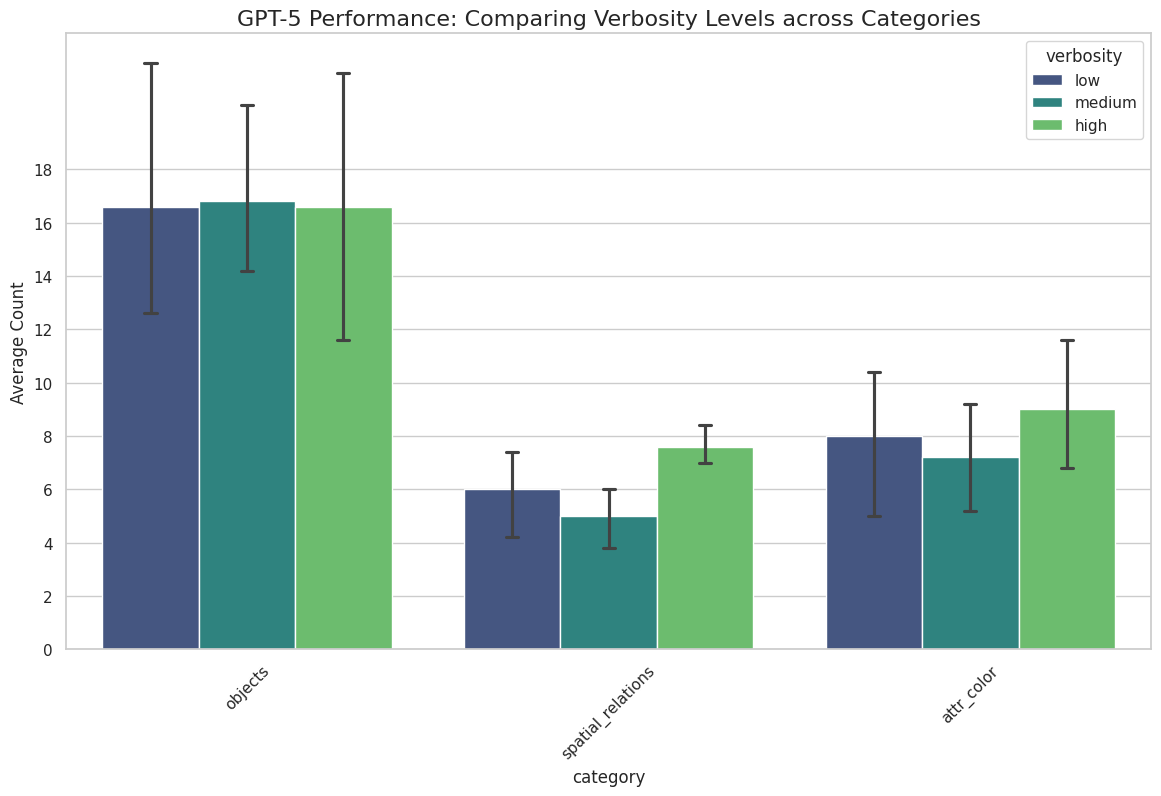

In [12]:
plt.figure(figsize=(14, 8))

sns.barplot(
    data=gpt_long,
    x='category',
    y='count',
    hue='verbosity',
    hue_order=['low', 'medium', 'high'],
    palette='viridis',
    capsize=.1
)

plt.title('GPT-5 Performance: Comparing Verbosity Levels across Categories', fontsize=16)
plt.ylabel('Average Count')
plt.xticks(rotation=45)
plt.yticks(range(0, 20, 2))
plt.show()

In [25]:
# --- 1. Prepare Human Data: One dot per participant ---
# Average across 'gt' images so each (uid, condition, category) has exactly one value
df_human_dots = df_attempt_3.groupby(
    ['uid', 'condition', 'category'], 
    as_index=False
)['count'].mean()

# --- 2. Prepare GPT Data: The Ceiling ---
# Filter for your desired verbosity and average across all images for a category mean
chosen_verbosity = 'medium' 
gpt_ceiling = gpt_long[gpt_long['verbosity'] == chosen_verbosity].groupby(
    'category'
)['count'].mean()

/tmp/ipykernel_592960/2184887283.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_human_dots = df_attempt_3.groupby(


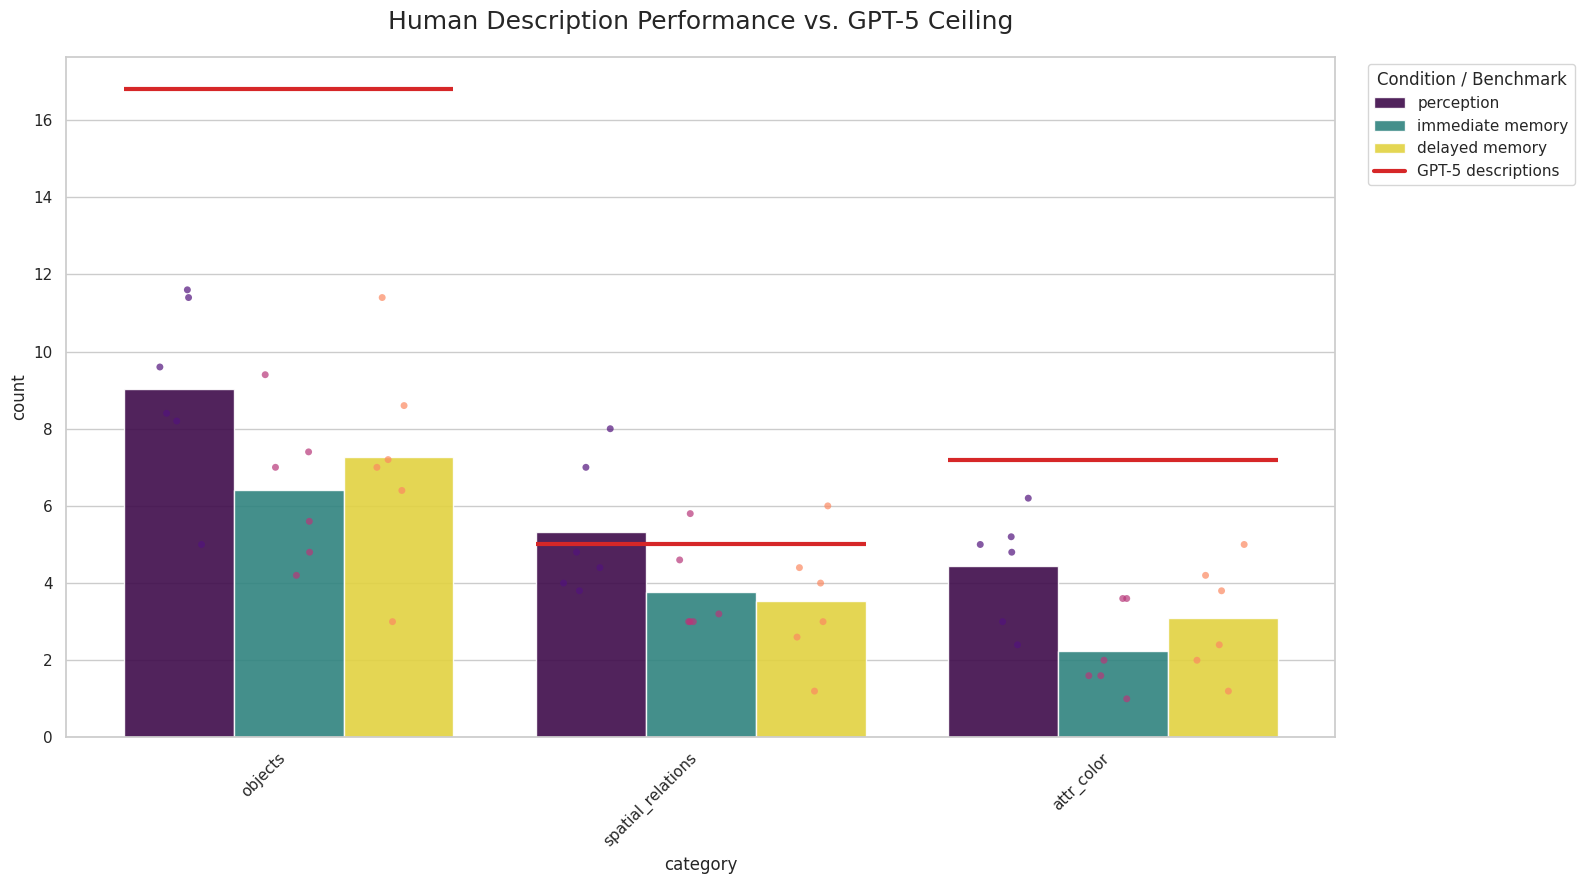

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the order and style
condition_order = ['perception', 'immediate memory', 'delayed memory']
df_human_dots['condition'] = pd.Categorical(df_human_dots['condition'], categories=condition_order, ordered=True)
category_list = selected_columns # Ensure this matches your x-axis order

plt.figure(figsize=(16, 9))
ax = sns.barplot(data=df_human_dots, x='category', y='count', hue='condition', palette=custom_palette, alpha=0.9, errorbar=None)
sns.stripplot(data=df_human_dots, x='category', y='count', hue='condition', dodge=True, palette='magma', alpha=0.7, jitter=0.2, size=5, legend=False)

# --- NEW: GPT Horizontal Bars per Category ---
# Define how wide you want each ceiling line to be (0.8 is roughly the width of the 3 bars)
line_width = 0.8 

for i, category in enumerate(category_list):
    y_val = gpt_ceiling[category]
    # xmin and xmax are relative to the category index (i)
    plt.hlines(y=y_val, xmin=i - line_width/2, xmax=i + line_width/2, 
               color='#d62728', linestyle='-', linewidth=3, zorder=5)
    
    # Optional: Add a single legend entry for the red line
    if i == 0:
        plt.plot([], [], color='#d62728', label=f'GPT-5 descriptions', linewidth=3)

# Final formatting
plt.title('Human Description Performance vs. GPT-5 Ceiling', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition / Benchmark', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# comparison with gpt and with wilma

In [29]:
df_wilma

,category,condition,count
0,objects,perception,9.4
1,objects,immediate memory,7.8
2,objects,delayed memory,7.0


In [30]:
# humans descriptions (3rd attempt) vs wilma (drawings) with gpt as a ceiling
# 1. Filter human description data for 'objects'
human_objs = df_human_dots[df_human_dots['category'] == 'objects'].copy()
human_objs['Type'] = 'Description'

# 2.
#add another column called type whos value is drawing:
df_wilma['Type'] = 'Drawing'

# 3. Combine them for plotting
comparison_df = pd.concat([human_objs, df_wilma], ignore_index=True)

# Ensure condition order
condition_order = ['perception', 'immediate memory', 'delayed memory']
comparison_df['condition'] = pd.Categorical(comparison_df['condition'], categories=condition_order, ordered=True)

In [34]:
comparison_df

,uid,condition,category,count,Type,type
0,17t99kvz1765301165519,perception,objects,9.600000,Description,NaN
1,17t99kvz1765301165519,immediate memory,objects,NaN,Description,NaN
2,17t99kvz1765301165519,delayed memory,objects,NaN,Description,NaN
3,26b1mnt51770668623350,perception,objects,NaN,Description,NaN
4,26b1mnt51770668623350,immediate memory,objects,NaN,Description,NaN
5,26b1mnt51770668623350,delayed memory,objects,7.400000,Description,NaN
6,6wvnde9x1767643758827,perception,objects,NaN,Description,NaN
7,6wvnde9x1767643758827,immediate memory,objects,5.600000,Description,NaN
8,6wvnde9x1767643758827,delayed memory,objects,NaN,Description,NaN
9,734m52011765314517645,perception,objects,5.000000,Description,NaN


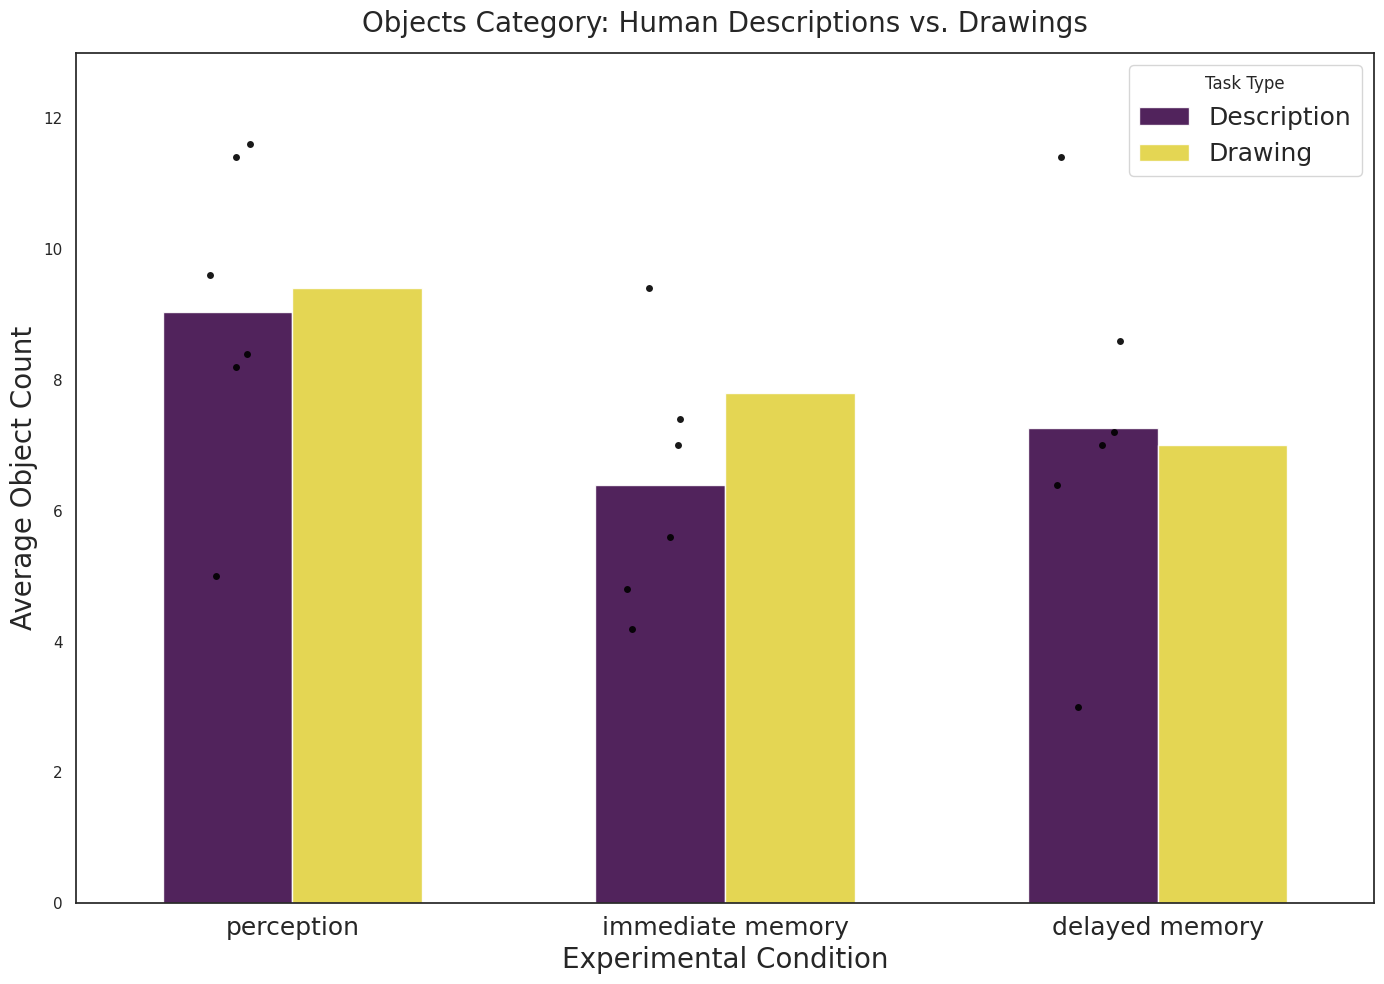

In [57]:
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

# --- A. Draw the Comparison Bars ---
ax = sns.barplot(
    data=comparison_df,
    x='condition',
    y='count',
    hue='Type',
    palette=['#440154', '#fde725'], # Dark purple for Descriptions, Yellow for Drawings
    alpha=0.9,
    errorbar=None,
    width=0.6
)

# 1. Move dots specifically to the Description bar
# We filter for 'Description' and disable dodge to control position manually
sns.stripplot(
    data=human_objs[human_objs['Type'] == 'Description'],
    x='condition',
    y='count',
    color='black', # Changed to black for visibility as requested previously
    alpha=0.9,
    jitter=0.1,
    size=5,
    # Manual shift: In a 2-hue bar plot, the left bar is at -0.15 
    # relative to the integer x-coordinate when width is 0.6
    native_scale=True, 
    legend=False
)
# Fix for the dot position: we shift the x-axis for the dots
# Note: In newer Seaborn, we can adjust the collection positions directly
for collection in ax.collections:
    if isinstance(collection, plt.matplotlib.collections.PathCollection):
        offsets = collection.get_offsets()
        offsets[:, 0] -= 0.15  # Shift dots left to center on the purple bar
        collection.set_offsets(offsets)

# --- C. Add the GPT Ceiling (Description Upper Limit) ---
# For 'objects', GPT was ~16.8 in your previous data
gpt_obj_limit = gpt_ceiling['objects'] 
line_width = 0.3  # Width of the individual ceiling caps

# # We iterate through the conditions and place a line over the first bar (Description)
# for i in range(len(condition_order)):
#     # In a 2-hue bar plot, the center of the first bar is at i - 0.2
#     x_pos = i - 0.2 
#     plt.hlines(
#         y=gpt_obj_limit, 
#         xmin=x_pos - line_width/2, 
#         xmax=x_pos + line_width/2, 
#         color='#d62728', linewidth=3, zorder=5
#     )

# Legend entry for the ceiling
# plt.plot([], [], color='#d62728', label='GPT-5 Description Limit', linewidth=3)

# --- D. Final Polish ---
plt.title('Objects Category: Human Descriptions vs. Drawings', fontsize=20, pad=15)
plt.ylabel('Average Object Count', fontsize=20)
plt.xlabel('Experimental Condition', fontsize=20)
plt.xticks(fontsize=18) # Tick labels (perception, memory, etc.)
plt.ylim(0, 13)# max(gpt_obj_limit, comparison_df['count'].max()) * 1.1)
plt.legend(title='Task Type', loc='upper right', fontsize=18)

plt.tight_layout()
plt.show()

# Hit rate - object accuracy measures

/tmp/ipykernel_435460/2509115049.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette="viridis")
/tmp/ipykernel_435460/2509115049.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette="viridis")
/tmp/ipykernel_435460/2509115049.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette="viridis")
/tmp/ipykernel_435460/2509115049.py:40: FutureWarning: 

Passing `palette` without assigning `hue

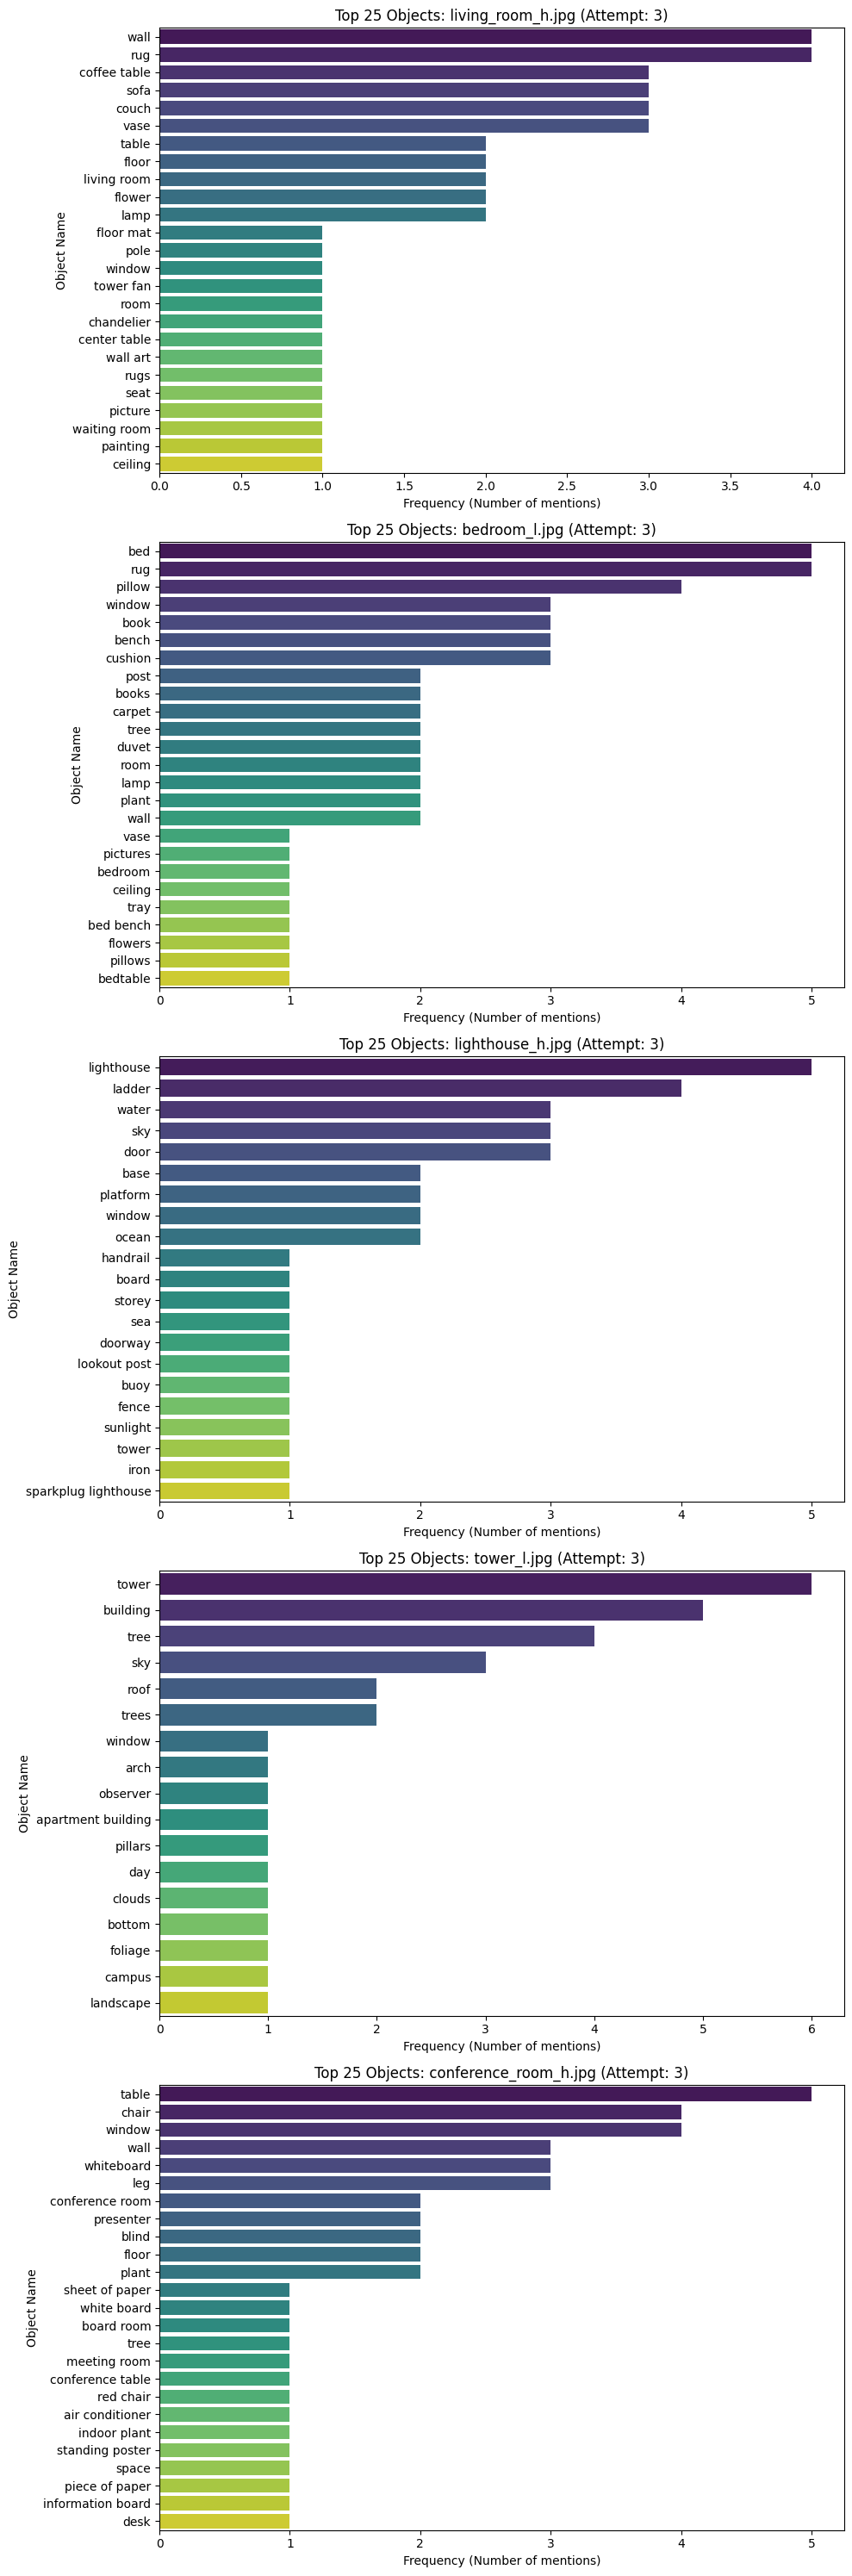

In [12]:
#now for #no feedback dfs:df_no_feedback_perc 

def plot_object_frequencies(df, attempt_filter=None, top_n=25):
    """
    Generates bar plots for the top N objects for each unique image (gt).
    """
    # 1. Optional Filtering (e.g., only looking at the final attempt)
    plot_df = df.copy()
    if attempt_filter:
        plot_df = plot_df[plot_df['attempt'] == attempt_filter]

    # 2. Data Cleaning: Ensure 'objects' column is a list
    # (Sometimes CSVs load lists as strings like "['bed', 'pillow']")
    def parse_objects(x):
        if isinstance(x, str):
            try:
                return ast.literal_eval(x)
            except:
                return []
        return x if isinstance(x, list) else []

    plot_df['objects'] = plot_df['objects'].apply(parse_objects)

    # 3. Setup plotting
    unique_images = plot_df['gt'].unique()
    n_images = len(unique_images)
    
    fig, axes = plt.subplots(nrows=n_images, ncols=1, figsize=(10, 6 * n_images))
    if n_images == 1: axes = [axes] # Handle single image case

    # 4. Iterate through each image and plot
    for i, img_name in enumerate(unique_images):
        # Filter for current image and "explode" the list of objects into individual rows
        img_data = plot_df[plot_df['gt'] == img_name]['objects'].explode()
        
        # Calculate counts
        counts = img_data.value_counts().head(top_n)
        
        # Create the bar plot
        sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette="viridis")
        
        axes[i].set_title(f"Top {top_n} Objects: {img_name} (Attempt: {attempt_filter if attempt_filter else 'All'})")
        axes[i].set_xlabel("Frequency (Number of mentions)")
        axes[i].set_ylabel("Object Name")

    plt.tight_layout()
    plt.show()

# --- HOW TO USE ---
# Assuming your dataframe is named 'df'
# To see everything:
# plot_object_frequencies(df)

# To see only the 3rd attempt (likely the most detailed):
plot_object_frequencies(df_feedback_perc , attempt_filter=3)

## Exporting a csv for each image will *all* objects mentioned
and printing top and bottom items per image

In [ ]:
import pandas as pd
import ast
import os

def get_object_consensus_report_and_export(df, save_path=".", attempt_filter=None):
    """
    Groups objects by frequency for each image, prints a report,
    exports individual CSVs per image, and prints a global summary.
    """
    report_df = df.copy()
    
    # 1. Filter by attempt
    if attempt_filter:
        report_df = report_df[report_df['attempt'] == attempt_filter]
    
    # 2. Parse string lists into Python lists
    def parse_objects(x):
        if isinstance(x, str):
            try: return ast.literal_eval(x)
            except: return []
        return x if isinstance(x, list) else []

    report_df['objects'] = report_df['objects'].apply(parse_objects)
    
    # 3. Explode and count
    exploded = report_df.explode('objects')
    exploded = exploded[exploded['objects'].notna() & (exploded['objects'] != "")]
    
    # Group by image and object name to get counts per image
    counts = exploded.groupby(['gt', 'objects']).size().reset_index(name='n')
    
    # ==========================================
    # 1. Calculate and Print Global Summaries (No Export)
    # ==========================================
    global_counts = exploded['objects'].value_counts().reset_index()
    global_counts.columns = ['object_name', 'total_appearances']
    
    top_20 = global_counts.head(20)
    least_30 = global_counts[global_counts['total_appearances'] < 3].tail(30)
    
    print(f"\n{'#'*60}")
    print(" GLOBAL SUMMARY: 20 MOST COMMON OBJECTS")
    print(f"{'#'*60}")
    print(top_20.to_string(index=False))
    
    print(f"\n{'#'*60}")
    print(" GLOBAL SUMMARY: 30 LEAST COMMON OBJECTS (Count < 3)")
    print(f"{'#'*60}")
    print(least_30.to_string(index=False))
    print("\nGenerating individual image reports and CSVs...\n")

    # ==========================================
    # 2. Generate the report AND CSV per image
    # ==========================================
    unique_images = counts['gt'].unique()
    
    for img in unique_images:
        img_data = counts[counts['gt'] == img]
        
        # --- EXPORT SEPARATE CSV PER IMAGE ---
        # Clean the image name just in case it contains characters invalid for filenames
        safe_img_name = str(img).replace('/', '_').replace('\\', '_').replace('.jpg', '').replace('.png', '')
        img_csv_path = os.path.join(save_path, f"counts_{safe_img_name}.csv")
        
        img_data.to_csv(img_csv_path, index=False)
        
        # --- PRINT THE CONSOLE REPORT ---
        print(f"\n{'='*60}")
        print(f" IMAGE: {img} (Attempt: {attempt_filter if attempt_filter else 'All'})")
        print(f" [Saved counts to: {img_csv_path}]")
        print(f"{'='*60}")
        
        # n = 1: High probability of hallucinations or extreme detail
        n1 = img_data[img_data['n'] <= 1]['objects'].tolist()
        print(f"\n[n=1] UNIQUE MENTIONS (Potential Hallucinations/Typos):")
        print(f"Count: {len(n1)}")
        print(f"Items: {', '.join(map(str, n1))}")
        
        # n <=3: Low consensus
        n3 = img_data[img_data['n'] <= 3]['objects'].tolist()
        print(f"\n[n<=3] LOW CONSENSUS - three or less:")
        print(f"Count: {len(n3)}")
        print(f"Items: {', '.join(map(str, n3))}")
        
        # n >= 4: Core objects
        n4_plus = img_data[img_data['n'] >= 4].sort_values(by='n', ascending=False)
        print(f"\n[n>=4] CORE OBJECTS (High Consensus):")
        for _, row in n4_plus.iterrows():
            print(f" - {row['objects']}: ({row['n']} times)")
            
    return counts, top_20, least_30

# --- RUNNING THE REPORT ---
# save_path = Path("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/objects_lists")
stats, top20_df, bottom30_df = get_object_consensus_report_and_export(
    df_feedback_perc, 
    save_path= save_path, 
    attempt_filter=None 
)


############################################################
 GLOBAL SUMMARY: 20 MOST COMMON OBJECTS
############################################################
object_name  total_appearances
     window                 28
       wall                 27
        rug                 23
      table                 21
       tree                 19
      tower                 19
 lighthouse                 16
        bed                 15
        sky                 15
       vase                 13
      floor                 12
       room                 12
      chair                 12
   building                 11
        leg                 11
      bench                 10
    cushion                  9
      water                  9
      couch                  9
       sofa                  9

############################################################
 GLOBAL SUMMARY: 30 LEAST COMMON OBJECTS (Count < 3)
############################################################
          

In [ ]:
#objects lists:

# Statistical Analysis
## Checking the distribution of the data for normality
## ANOVA or mixed-effects models to compare conditions
## Post-hoc tests to identify specific differences between conditions
## effect size calculations to understand the magnitude of differences


## distribution manipultations

--- Shapiro-Wilk Normality Tests ---
1. Regular Data                     | Statistic: 0.9418 | p-value: 7.5298e-09
2. Log Transformation (log(x+c))    | Statistic: 0.9718 | p-value: 3.6547e-05
3. Reciprocal (1/(x+c))             | Statistic: 0.7564 | p-value: 1.0690e-19
4. Square Root Transformation       | Statistic: 0.9823 | p-value: 2.0011e-03
5. Box-Cox Transformation           | Statistic: 0.9852 | p-value: 6.9266e-03


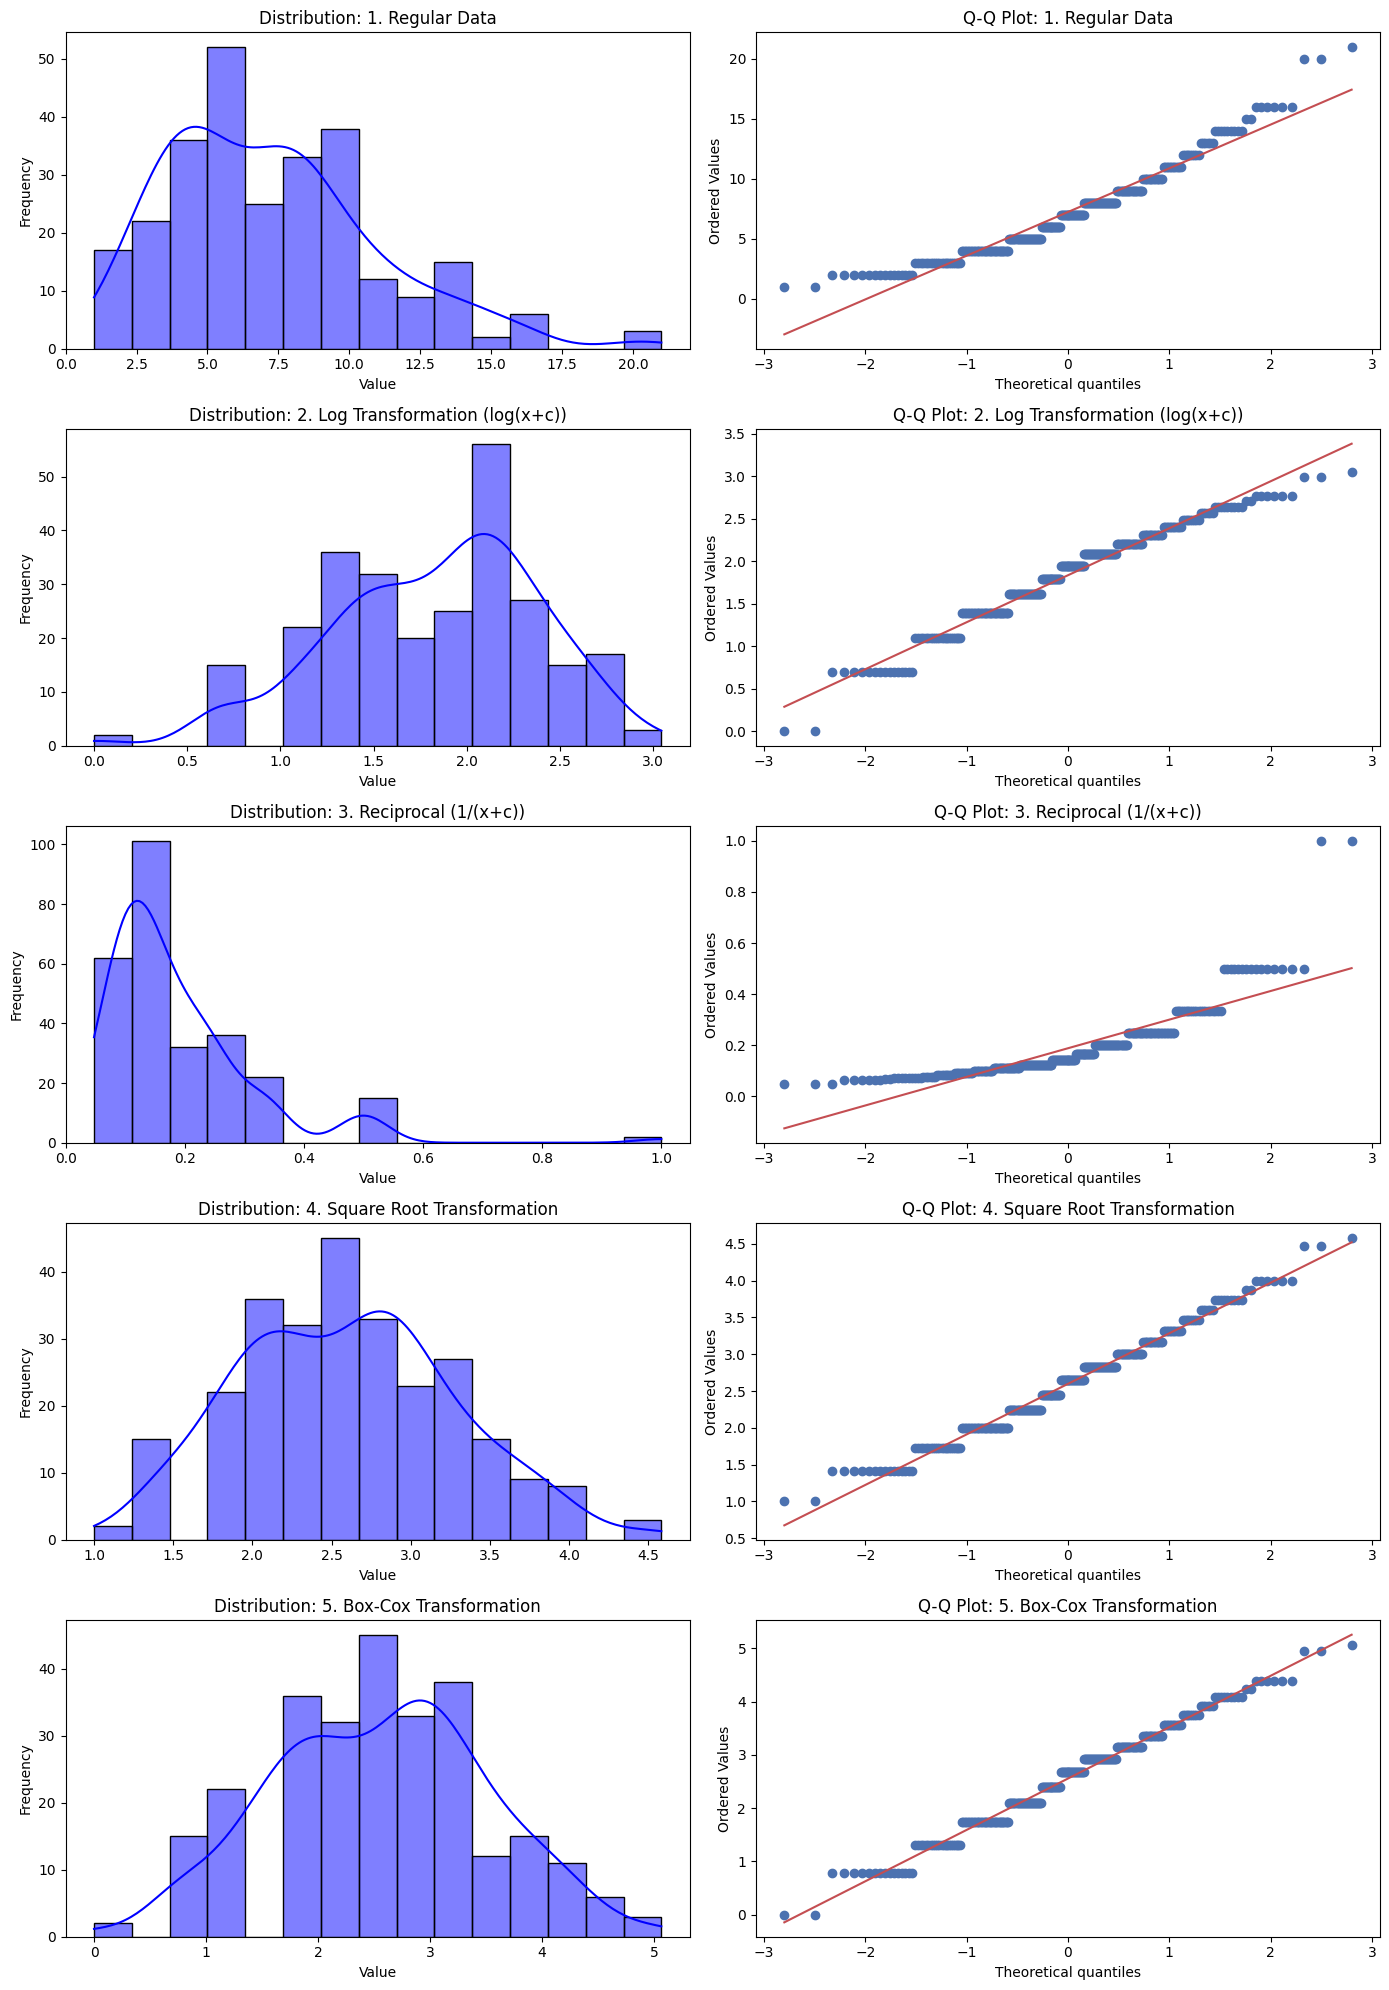

The optimal Box-Cox lambda (λ) value chosen is: 0.3103

--- Distribution Properties (Regular Data) ---
Mean of counts: 7.22
Variance of counts: 13.90
Note: Variance is noticeably larger than the mean (overdispersion). A Negative Binomial model might be better than Poisson.


In [65]:
## 1. Filter for the 'objects' category and isolate the counts
objects_data = long[long['category'] == 'objects'].copy()
counts = objects_data['count']

# performing transformations on the data to try to achieve normality

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
plt.style.use('default')
# 1. Filter for the 'objects' category and isolate the counts
objects_data = long[long['category'] == 'objects'].copy()
counts = objects_data['count']

# Check if there are zeros to avoid log(0) or 1/0 errors.
# If zeros exist, we add 1 to the data for the transformations.
c = 1 if (counts == 0).any() else 0 

# Unpack both the transformed data AND the lambda value
transformed_data, best_lambda = stats.boxcox(counts + c)

# Define the dictionary of transformations
transformations = {
    "1. Regular Data": counts,
    "2. Log Transformation (log(x+c))": np.log1p(counts) if c == 1 else np.log(counts),
    "3. Reciprocal (1/(x+c))": 1 / (counts + c),
    "4. Square Root Transformation": np.sqrt(counts),
    "5. Box-Cox Transformation":  transformed_data # Box-Cox requires positive > 0
}

# 2. Visual Check: Create a grid of Histograms and Q-Q Plots
fig, axes = plt.subplots(nrows=len(transformations), ncols=2, figsize=(14, 4 * len(transformations)))

print("--- Shapiro-Wilk Normality Tests ---")

for i, (name, data) in enumerate(transformations.items()):
    # Histogram & Density Plot
    sns.histplot(data, kde=True, bins=15, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Distribution: {name}')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')
    
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot: {name}')
    
    # Statistical Check for each transformation
    stat, p_value = stats.shapiro(data)
    print(f"{name:35} | Statistic: {stat:.4f} | p-value: {p_value:.4e}")

plt.tight_layout()
plt.savefig(graphs_path / 'normality_transformations-for_all_object_count_data.png', bbox_inches='tight')
plt.show()

# 3. Check for Poisson vs. Negative Binomial on Regular Data
mean_count = counts.mean()
var_count = counts.var()
print(f"The optimal Box-Cox lambda (λ) value chosen is: {best_lambda:.4f}")
print("\n--- Distribution Properties (Regular Data) ---")
print(f"Mean of counts: {mean_count:.2f}")
print(f"Variance of counts: {var_count:.2f}")

if var_count > (mean_count * 1.5):
    print("Note: Variance is noticeably larger than the mean (overdispersion). A Negative Binomial model might be better than Poisson.")
else:
    print("Note: Mean and Variance are relatively close. A Poisson model is likely appropriate.")

distribution manipulations for averaged gt data (used for ANOVA)

--- Shapiro-Wilk Normality Tests ---
1. Regular Data                     | Statistic: 0.9474 | p-value: 1.9215e-02
2. Log Transformation (log(x+c))    | Statistic: 0.9631 | p-value: 9.5126e-02
3. Reciprocal (1/(x+c))             | Statistic: 0.9062 | p-value: 4.6839e-04
4. Square Root Transformation       | Statistic: 0.9636 | p-value: 1.0008e-01
5. Box-Cox Transformation           | Statistic: 0.9653 | p-value: 1.1873e-01


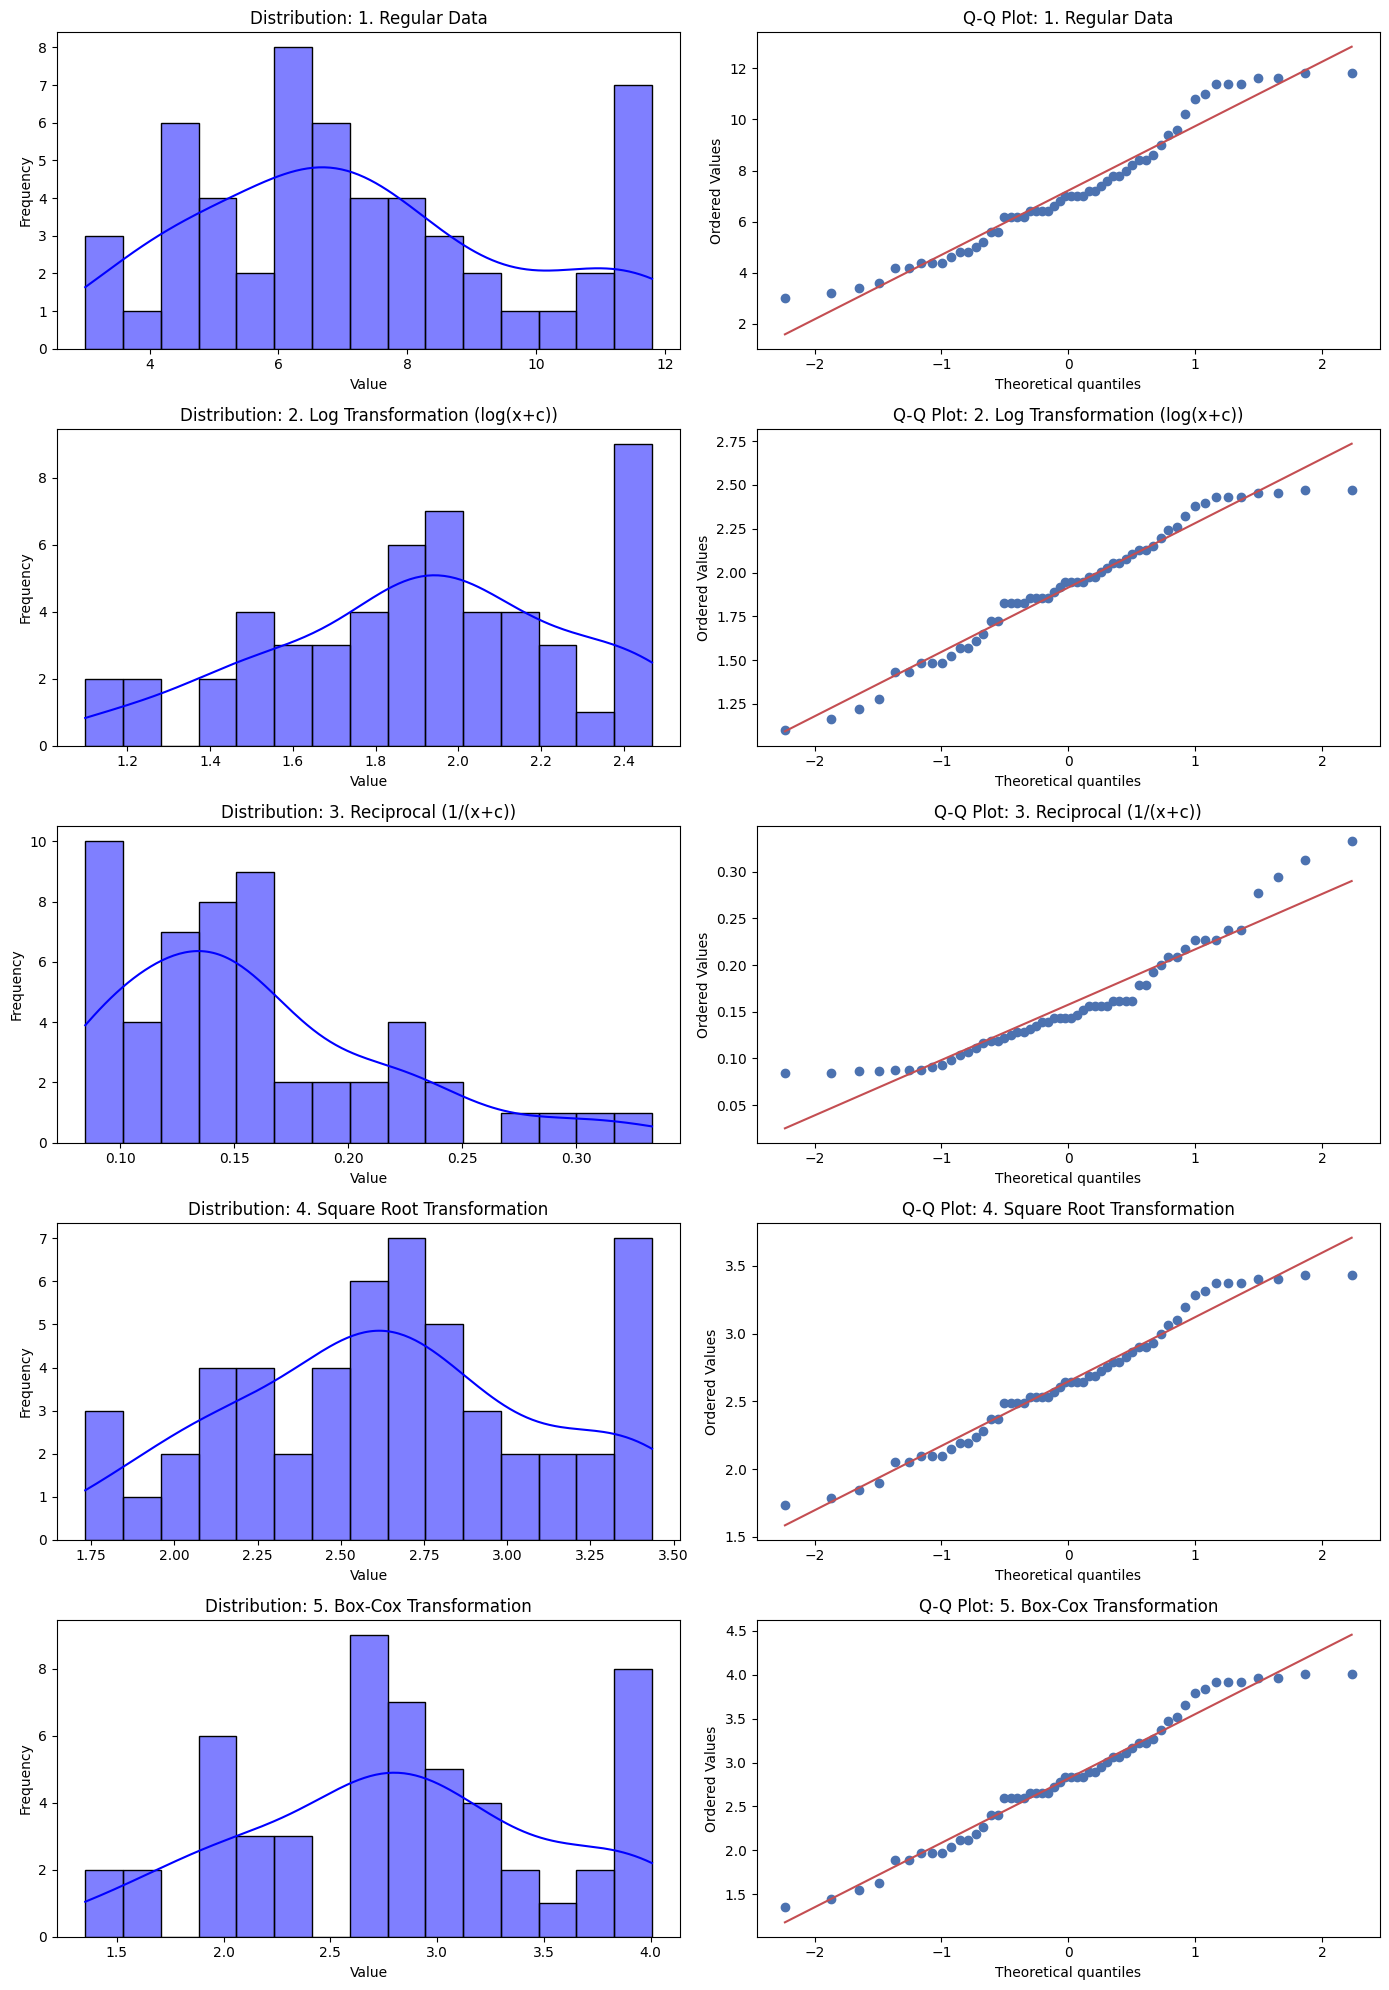

The optimal Box-Cox lambda (λ) value chosen is: 0.3652

--- Distribution Properties (Regular Data) ---
Mean of counts: 7.22
Variance of counts: 6.29
Note: Mean and Variance are relatively close. A Poisson model is likely appropriate.


In [66]:
#now same thing but when gt images are averaged
objects_participant = long[long['category'] == 'objects'].groupby(
    ['uid', 'condition', 'attempt'],
    as_index=False
)['count'].mean()   
counts= objects_participant['count']

# performing transformations on the data to try to achieve normality

# Check if there are zeros to avoid log(0) or 1/0 errors.
# If zeros exist, we add 1 to the data for the transformations.
c = 1 if (counts == 0).any() else 0 


# Unpack both the transformed data AND the lambda value
transformed_data, best_lambda = stats.boxcox(counts + c)

# Define the dictionary of transformations
transformations = {
    "1. Regular Data": counts,
    "2. Log Transformation (log(x+c))": np.log1p(counts) if c == 1 else np.log(counts),
    "3. Reciprocal (1/(x+c))": 1 / (counts + c),
    "4. Square Root Transformation": np.sqrt(counts),
    "5. Box-Cox Transformation": transformed_data # Box-Cox requires positive > 0
}

# 2. Visual Check: Create a grid of Histograms and Q-Q Plots
fig, axes = plt.subplots(nrows=len(transformations), ncols=2, figsize=(14, 4 * len(transformations)))

print("--- Shapiro-Wilk Normality Tests ---")

for i, (name, data) in enumerate(transformations.items()):
    # Histogram & Density Plot
    sns.histplot(data, kde=True, bins=15, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Distribution: {name}')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')
    
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot: {name}')
    
    # Statistical Check for each transformation
    stat, p_value = stats.shapiro(data)
    print(f"{name:35} | Statistic: {stat:.4f} | p-value: {p_value:.4e}")

plt.tight_layout()
plt.savefig(graphs_path / 'normality_transformations-for_averaged_data.png', bbox_inches='tight')
plt.show()

# 3. Check for Poisson vs. Negative Binomial on Regular Data
mean_count = counts.mean()
var_count = counts.var()
print(f"The optimal Box-Cox lambda (λ) value chosen is: {best_lambda:.4f}")
print("\n--- Distribution Properties (Regular Data) ---")
print(f"Mean of counts: {mean_count:.2f}")
print(f"Variance of counts: {var_count:.2f}")

if var_count > (mean_count * 1.5):
    print("Note: Variance is noticeably larger than the mean (overdispersion). A Negative Binomial model might be better than Poisson.")
else:
    print("Note: Mean and Variance are relatively close. A Poisson model is likely appropriate.")

# removing the outlier participant in the delay condition (over performing)

--- Shapiro-Wilk Normality Tests ---
1. Regular Data                     | Statistic: 0.9593 | p-value: 7.7859e-02
2. Log Transformation (log(x+c))    | Statistic: 0.9725 | p-value: 2.8013e-01
3. Reciprocal (1/(x+c))             | Statistic: 0.9120 | p-value: 1.0860e-03
4. Square Root Transformation       | Statistic: 0.9749 | p-value: 3.5041e-01
5. Box-Cox Transformation           | Statistic: 0.9762 | p-value: 3.9315e-01


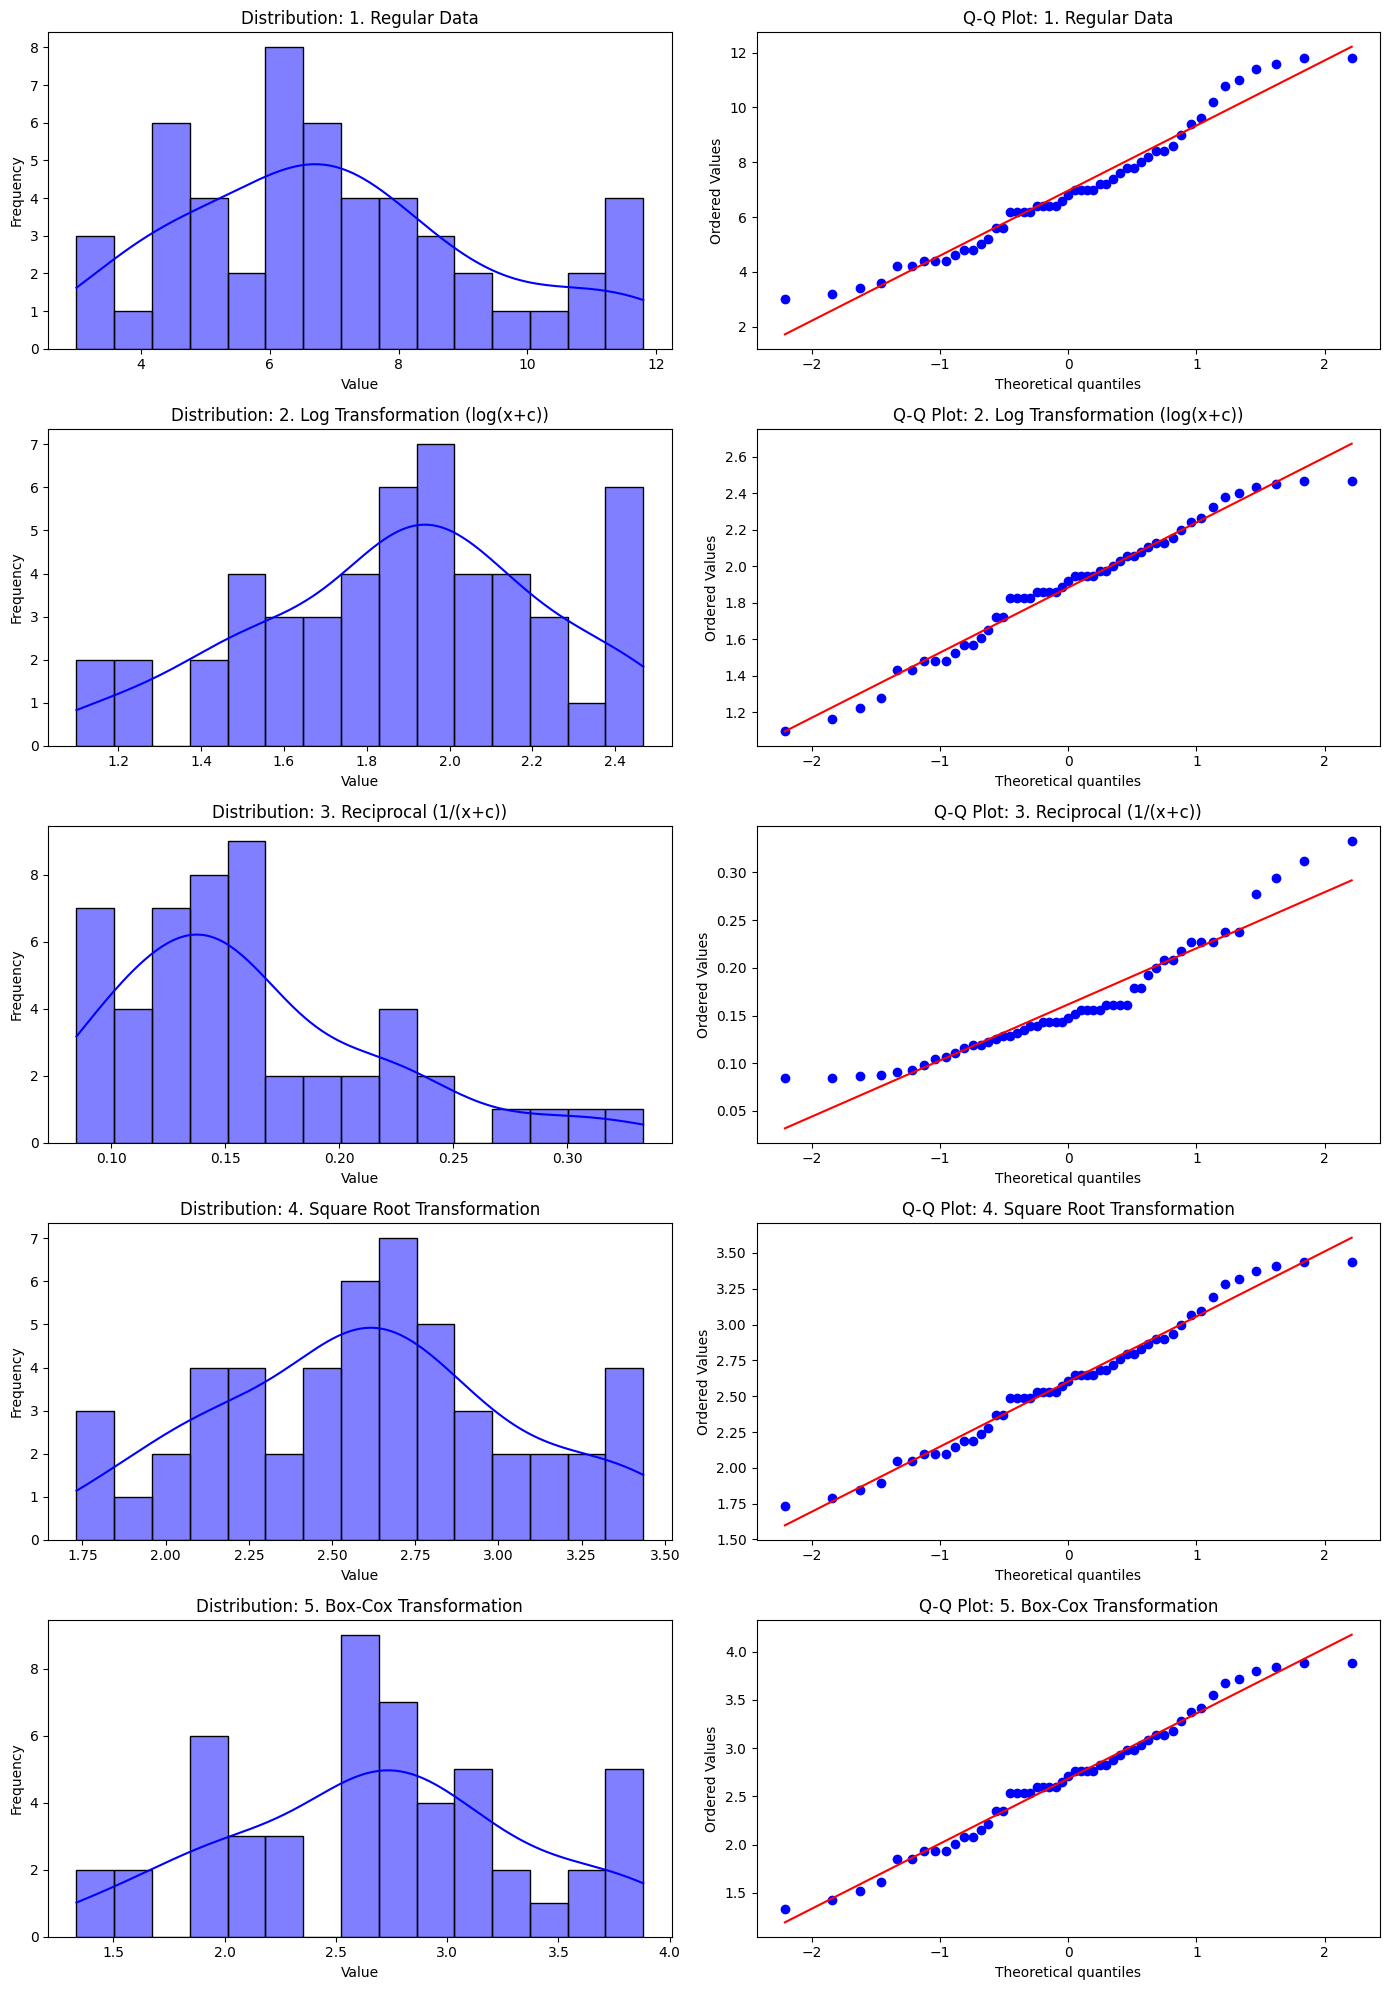

The optimal Box-Cox lambda (λ) value chosen is: 0.3428

--- Distribution Properties (Regular Data) ---
Mean of counts: 6.97
Variance of counts: 5.53
Note: Mean and Variance are relatively close. A Poisson model is likely appropriate.


In [15]:
# turning df clean into a long dataframe:
# converting wide to long and adding a count column for the number of items in each category
# required id columns (adjust if your names differ)
id_cols = ["condition", "attempt", "uid", "gt"]

long_clean = df_clean.melt(
    id_vars=id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

def safe_len(x):
    """Length for list-like; 0 for NaN/None; 1 for scalar non-list values."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x)
    return 1

long_clean["count"] = long_clean["items"].apply(safe_len)

# Keep category order as selected_columns
long_clean["category"] = pd.Categorical(long_clean["category"], categories=selected_columns, ordered=True)


#now same thing but when gt images are averaged
objects_participant = long_clean[long_clean['category'] == 'objects'].groupby(
    ['uid', 'condition', 'attempt'],
    as_index=False
)['count'].mean()   
counts= objects_participant['count']

# performing transformations on the data to try to achieve normality

# Check if there are zeros to avoid log(0) or 1/0 errors.
# If zeros exist, we add 1 to the data for the transformations.
c = 1 if (counts == 0).any() else 0 

transformed_data, best_lambda = stats.boxcox(counts + c)

# Define the dictionary of transformations
transformations = {
    "1. Regular Data": counts,
    "2. Log Transformation (log(x+c))": np.log1p(counts) if c == 1 else np.log(counts),
    "3. Reciprocal (1/(x+c))": 1 / (counts + c),
    "4. Square Root Transformation": np.sqrt(counts),
    "5. Box-Cox Transformation": transformed_data # Box-Cox requires positive > 0
}

# 2. Visual Check: Create a grid of Histograms and Q-Q Plots
fig, axes = plt.subplots(nrows=len(transformations), ncols=2, figsize=(14, 4 * len(transformations)))

print("--- Shapiro-Wilk Normality Tests ---")

for i, (name, data) in enumerate(transformations.items()):
    # Histogram & Density Plot
    sns.histplot(data, kde=True, bins=15, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Distribution: {name}')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')
    
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f'Q-Q Plot: {name}')
    
    # Statistical Check for each transformation
    stat, p_value = stats.shapiro(data)
    print(f"{name:35} | Statistic: {stat:.4f} | p-value: {p_value:.4e}")

plt.tight_layout()
# plt.savefig(graphs_path / 'normality_transformations-for_averaged_gt_removed_outlier.png', bbox_inches='tight')
plt.show()

# 3. Check for Poisson vs. Negative Binomial on Regular Data
mean_count = counts.mean()
var_count = counts.var()
print(f"The optimal Box-Cox lambda (λ) value chosen is: {best_lambda:.4f}")
print("\n--- Distribution Properties (Regular Data) ---")
print(f"Mean of counts: {mean_count:.2f}")
print(f"Variance of counts: {var_count:.2f}")

if var_count > (mean_count * 1.5):
    print("Note: Variance is noticeably larger than the mean (overdispersion). A Negative Binomial model might be better than Poisson.")
else:
    print("Note: Mean and Variance are relatively close. A Poisson model is likely appropriate.")

Analysis 1: The 3rd Attempt Comparison
Goal: Compare the final performance across the 3 conditions - is there a difference in performance between conditions?
§Data Preparation:
- Filter the dataset to include only the 3rd attempt for each participant.
- Ensure that the data is clean and properly formatted for analysis.


In [19]:
long_clean.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/long_pilot_data_with_digit_span_clean_data.csv", index=False)

In [29]:

# --- Step 1: Prepare the Data ---
# Just like before, we filter for objects and average across the 5 images (trials)
objects_data = long[long['category'] == 'objects']
averaged_data = objects_data.groupby(['uid', 'condition', 'attempt'], as_index=False)['count'].mean()

# Now, isolate ONLY Attempt 3 for this specific analysis
attempt3_data = averaged_data[averaged_data['attempt'] == 3].copy()

# --- Step 2: The One-Way ANOVA (Mimicking R's aov() or lm() + anova()) ---
# In R, you would write: model <- aov(count ~ condition, data=attempt3_data)
# In Python with statsmodels, we do this:

# 1. Fit the Ordinary Least Squares (OLS) model. 
# C(condition) tells statsmodels that 'condition' is Categorical, just like as.factor() in R.
model = smf.ols('count ~ C(condition)', data=attempt3_data).fit()

# 2. Generate the ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2) # typ=2 is standard for balanced designs
print("--- ANOVA Table ---")
print(anova_table)

print("\n")
print('!!! --- ANOVA Results Interpretation --- !!!')
print(f"---- p value for condition effect: {anova_table.loc['C(condition)', 'PR(>F)']:.4f} ----")
print(f"there is no significant effect, therefore we shouldn;t calculate effect size and do post hoc tests")


# --- Step 3: Calculate Effect Size (Eta-Squared) ---
# statsmodels doesn't print eta-squared by default, but the math is simple:
# Eta-squared = Sum of Squares (Condition) / Sum of Squares (Total)
ss_condition = anova_table.loc['C(condition)', 'sum_sq']
ss_residual = anova_table.loc['Residual', 'sum_sq']
ss_total = ss_condition + ss_residual

eta_squared = ss_condition / ss_total
print(f"\n--- Effect Size ---")
print(f"Eta-squared (η²): {eta_squared:.4f}")

# --- Step 4: Post-Hoc Testing (Tukey HSD) ---
# If your p-value (PR(>F) in the ANOVA table) is < 0.05, run this to see WHICH groups differ.
print("\n--- Tukey HSD Post-Hoc Test ---")
tukey = pairwise_tukeyhsd(endog=attempt3_data['count'],    # The dependent variable
                          groups=attempt3_data['condition'], # The independent variable
                          alpha=0.05)                      # Significance level
print(tukey)

--- ANOVA Table ---
                 sum_sq    df         F    PR(>F)
C(condition)  21.613333   2.0  1.881238  0.186642
Residual      86.166667  15.0       NaN       NaN


!!! --- ANOVA Results Interpretation --- !!!
---- p value for condition effect: 0.1866 ----
there is no significant effect, therefore we shouldn;t calculate effect size and do post hoc tests

--- Effect Size ---
Eta-squared (η²): 0.2005

--- Tukey HSD Post-Hoc Test ---
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
  delayed memory immediate memory  -0.8667 0.8081  -4.461 2.7276  False
  delayed memory       perception   1.7667 0.4291 -1.8276  5.361  False
immediate memory       perception   2.6333 0.1721  -0.961 6.2276  False
-----------------------------------------------------------------------


Analysis 2: The Learning Curve (All Attempts)
Goal: See if there is improvement across attempts, and if that improvement differs by condition

This ANOVA is going to give you three distinct p-values, answering three different questions:

1. **Main Effect of Condition (Between-Subjects):** Ignoring *which* attempt it was, did the three groups differ in their overall average performance?  
2. **Main Effect of Attempt (Within-Subjects):** Ignoring *which* group people were in, did participants' scores generally change from Attempt 1 to 2 to 3? (This proves if a learning curve exists at all).  
3. **The Interaction Effect (Condition $\\times$ Attempt):** This is the core of your research question. Does the *trajectory* of the learning curve depend on the condition?  
   * *Example:* Maybe the Perception group starts high and stays flat, but the Delayed group starts low and improves dramatically. If the slopes of their learning curves are different, this interaction will be significant.

In [13]:
objects_data = long[long['category'] == 'objects']
averaged_data = objects_data.groupby(['uid', 'condition', 'attempt'], as_index=False)['count'].mean()

# --- Step 1: Ensure Data Types ---
# pingouin is strict about data types. Ensure 'uid', 'condition', and 'attempt' are treated as categories/objects, not continuous math numbers.
averaged_data['uid'] = averaged_data['uid'].astype(str)
averaged_data['condition'] = averaged_data['condition'].astype(str)
averaged_data['attempt'] = averaged_data['attempt'].astype(str)

# --- Step 2: The Two-Way Mixed ANOVA ---
# dv = Dependent Variable
# within = Within-subjects factor (repeated measures)
# between = Between-subjects factor
# subject = Subject identifier
aov_results = pg.mixed_anova(dv='count', 
                             within='attempt', 
                             between='condition', 
                             subject='uid', 
                             data=averaged_data)

# Print the beautifully formatted results table
print("--- Two-Way Mixed ANOVA Results ---")
print(aov_results.round(4))

--- Two-Way Mixed ANOVA Results ---
        Source       SS  DF1  DF2       MS       F   p_unc  p_GG_corr     np2  \
0    condition  36.1170    2   15  18.0585  0.9793  0.3983        NaN  0.1155   
1      attempt   6.0504    2   30   3.0252  7.9363  0.0017     0.0094  0.3460   
2  Interaction   3.4207    4   30   0.8552  2.2435  0.0879        NaN  0.2303   

      eps sphericity  W_spher  p_spher  
0     NaN        NaN      NaN      NaN  
1  0.6744      False   0.5171   0.0051  
2     NaN        NaN      NaN      NaN  


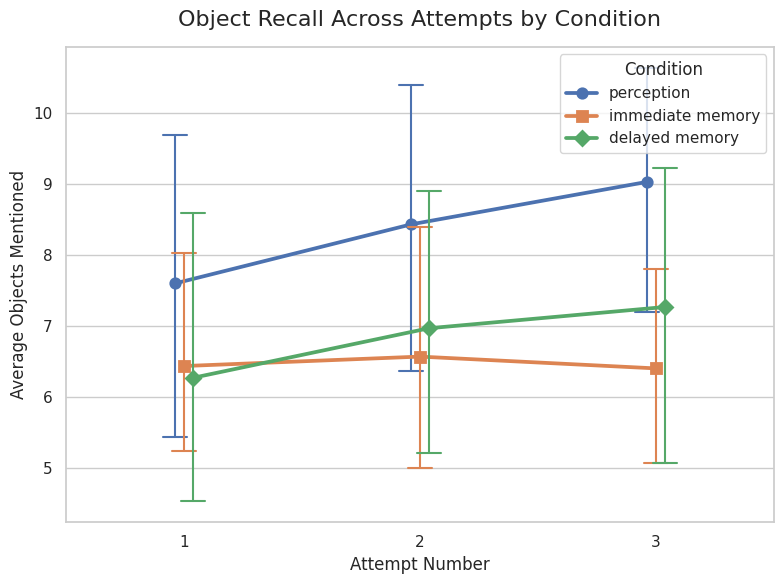

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visual style
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Create a point plot
# x = the repeated measure (time)
# y = the dependent variable
# hue = the distinct groups (conditions)
sns.pointplot(data=averaged_data, 
              x='attempt', 
              y='count', 
              hue='condition',
              dodge=True,     # Slightly separates the points so error bars don't overlap
              markers=['o', 's', 'D'], # Different shapes for different conditions
              capsize=.1,     # Adds caps to the error bars
              err_kws={'linewidth': 1.5}) # Formatting for error bars

# Customize labels and title
plt.title('Object Recall Across Attempts by Condition', fontsize=16, pad=15)
plt.xlabel('Attempt Number', fontsize=12)
plt.ylabel('Average Objects Mentioned', fontsize=12)
plt.legend(title='Condition')

plt.tight_layout()
plt.show()

/tmp/ipykernel_104539/2681295680.py:42: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=objects_data,


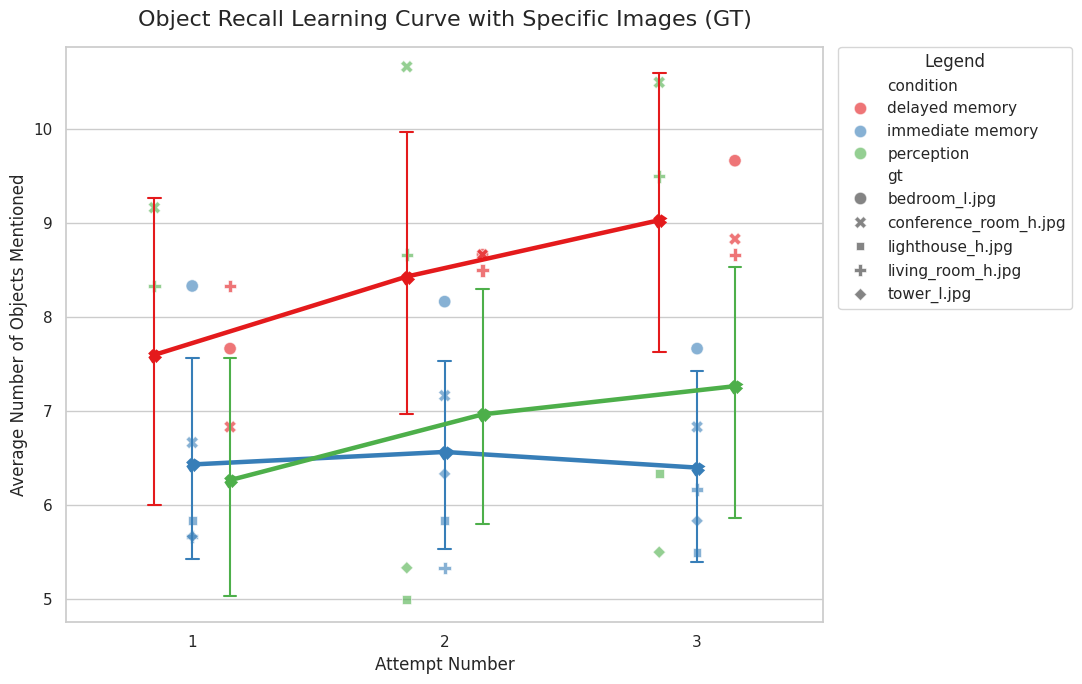

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Step 1: Prepare the Data ---
objects_data = long[long['category'] == 'objects'].copy()

# Ensure attempt is numeric so we can mathematically shift the x-axis
objects_data['attempt_num'] = objects_data['attempt'].astype(int)

# Calculate average per GT image, per condition, per attempt
gt_averages = objects_data.groupby(['condition', 'attempt_num', 'gt'], as_index=False)['count'].mean()

# --- Step 2: Calculate X-Axis Offsets for Alignment ---
# Seaborn's pointplot places categories at x=0, x=1, x=2. 
# We calculate manual offsets so the scatterplot dots perfectly hug the dodged lines.
conditions = objects_data['condition'].unique()
# A pointplot dodge of 0.3 means the lines are at -0.15, 0, and +0.15 from the center
offsets = dict(zip(conditions, [-0.15, 0, 0.15])) 

# Create the exact X-coordinate for each dot (zero-indexing the attempt: 1->0, 2->1, 3->2)
gt_averages['x_pos'] = (gt_averages['attempt_num'] - 1) + gt_averages['condition'].map(offsets)

# --- Step 3: Create the Plot ---
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set1", n_colors=len(conditions))

# 1. Plot the individual GT images (Using scatterplot for the shapes)
# hue = condition (color), style = gt (shape)
sns.scatterplot(data=gt_averages, 
                x='x_pos', 
                y='count', 
                hue='condition', 
                style='gt',       # Maps the 5 images to 5 distinct shapes
                s=80,             # Marker size
                alpha=0.6,        # Semi-transparent to act as background
                palette=palette,
                legend='full')    # Generates the comprehensive legend

# 2. Plot the main learning curves on top
sns.pointplot(data=objects_data, 
              x='attempt_num', 
              y='count', 
              hue='condition',
              dodge=0.3,          # Matches the spread of our custom offsets
              markers='X',        # Uses an 'X' for the main average to distinguish from GT shapes
              scale=1.2,          # Makes the average marker slightly larger
              capsize=.05,    
              err_kws={'linewidth': 1.5},
              palette=palette,
              legend=False)       # Suppress duplicate legend

# --- Step 4: Formatting ---
plt.title('Object Recall Learning Curve with Specific Images (GT)', fontsize=16, pad=15)
plt.xlabel('Attempt Number', fontsize=12)
plt.ylabel('Average Number of Objects Mentioned', fontsize=12)

# Ensure the x-axis displays the correct attempt numbers instead of 0, 1, 2
plt.xticks(ticks=[0, 1, 2], labels=['1', '2', '3']) 

# Move the large, combined legend outside the plot so it doesn't cover data
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Legend")

plt.tight_layout()
plt.show()

# now let's perform anova with the transformed data - sqaure root of the data

# Path B: we perform the same 2 analysis but now with GLMMs (instead of ANOVA) so no averaging across participants, but instead we model participant variability as a random effect. This allows us to use all the data points (all attempts) without averaging, and it accounts for the fact that some participants may be generally better or worse than others.


In [20]:
#I made a regular analysis and then changed to "Treatment" to change the alphabetical order
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Step 1: Prepare the Raw Data ---
# Filter for 'objects' and ONLY Attempt 3
objects_raw = long[long['category'] == 'objects'].copy()
attempt3_raw = objects_raw[objects_raw['attempt'] == 3].copy()

# Ensure our grouping variables are treated as categories/strings
attempt3_raw['uid'] = attempt3_raw['uid'].astype(str)
attempt3_raw['gt'] = attempt3_raw['gt'].astype(str)

# --- Step 2: Define and Fit the Mixed Model ---
# 1. The formula: 'count ~ C(condition)' defines the Fixed Effect.
# 2. groups='uid': This is our first Random Effect (Participant intercept).
# 3. vc_formula={'gt': '0 + C(gt)'}: This adds our second Random Effect (Image intercept). 
#    This creates a "Crossed Random Effects" model.

model = smf.mixedlm("count ~ C(condition)", # shifting focus to measure another difference: "count ~ C(condition, Treatment('immediate memory'))"
                    data=attempt3_raw, 
                    groups=attempt3_raw["uid"], 
                    vc_formula={"gt": "0 + C(gt)"})

result = model.fit()

# --- Step 3: Print the Results ---
print(result.summary())

                   Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       count    
No. Observations:         90            Method:                   REML     
No. Groups:               18            Scale:                    6.5404   
Min. group size:          5             Log-Likelihood:           -240.3944
Max. group size:          5             Converged:                Yes      
Mean group size:          5.0                                              
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         7.267    0.102 71.057 0.000  7.066  7.467
C(condition)[T.immediate memory] -0.867    0.742 -1.168 0.243 -2.321  0.587
C(condition)[T.perception]        1.767    0.608  2.907 0.004  0.576  2.958
gt Var                         

/mnt/hdd/anatkorol/Imagination_in_translation/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


# Analysis 2: Analysis 2: The Learning Curve (All Attempts) - with LMM
## Goal: See if there is improvement across attempts, and if that improvement differs by condition
### Note: again, we still assume normal distribution



In [38]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Step 1: Prepare the Data ---
# Filter for 'objects' across ALL attempts
objects_data = long[long['category'] == 'objects'].copy()

# Ensure our grouping variables and factors are treated as strings/categories
objects_data['uid'] = objects_data['uid'].astype(str)
objects_data['gt'] = objects_data['gt'].astype(str)
objects_data['condition'] = objects_data['condition'].astype(str)
objects_data['attempt'] = objects_data['attempt'].astype(str) 

# --- Step 2: Define and Fit the Two-Way LMM ---
# Formula: count ~ condition + attempt + (condition * attempt)
formula = "count ~ C(condition) * C(attempt)"

print("Fitting the LMM for the Learning Curve...")
model = smf.mixedlm(formula, 
                    data=objects_data, 
                    groups=objects_data["uid"],    # Random intercept for Participant
                    vc_formula={"gt": "0 + C(gt)"} # Random intercept for Image
                   )

result = model.fit()

# --- Step 3: Print the Results ---
print(result.summary())

Fitting the LMM for the Learning Curve...
                           Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             count    
No. Observations:             270                 Method:                         REML     
No. Groups:                   18                  Scale:                          1.2374   
Min. group size:              15                  Log-Likelihood:                 -562.2964
Max. group size:              15                  Converged:                      Yes      
Mean group size:              15.0                                                         
-------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                         6.267    0.670 